# C15 · Code walkthrough: `export/openvsp/` (geometry, structure, FE decks, aero cross-check)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the optional post-solve package `src/aircraft_closure/export/openvsp/` and the
five examples that drive it.

**What runs here and what does not.** OpenVSP (the `openvsp` Python API), PyVista and CalculiX (`ccx`) are not
installed on this machine. Everything that is pure Python runs on real numbers: the geometry snapshot, the V-tail
rule, the layout-based structure sizing, the AFDD-to-shell mapping, the CalculiX deck writer and its result parsers,
and the AeroSandbox side of the aero comparison. For the OpenVSP calls, section 0 installs a small **recording
stand-in** for the `openvsp` module (defined in this notebook, not in the repo). It lets `build_openvsp_model` and
`build_structure` execute so we can see the model tree and every parameter value they would send. It meshes nothing
and computes nothing; the results that need real OpenVSP or CalculiX are quoted from the design log with their
file and line.

| Module | Lines | What it holds |
|---|---|---|
| `export/__init__.py`, `export/openvsp/__init__.py` | 1 + 1 | package docstrings only |
| `snapshot.py` | 260 | `GeometrySnapshot` and its parts (plain floats), V-tail rule, the Halo drawing `halo_plan027_snapshot()`, `to_asb()` |
| `model.py` | 268 | OpenVSP outer mold line: bodies, surfaces, tilting nacelle group, sets, Modes, STEP/STL export |
| `render.py` | 132 | PyVista off-screen renders of the STL exports and of the structure |
| `structure.py` | 197 | OpenVSP FEA structures (wing box, fuselage, V-tail) and mesh export (STL, CalculiX, Nastran, mass) |
| `structure_check.py` | 266 | layout-based primary-structure sizing (closed form): box gauges, elliptic loads, fuselage skin |
| `fe_wing.py` | 311 | CalculiX wing-box check: AFDD-to-shell mapping, deck writer, mode and static result parsers |
| `aero.py` | 126 | VSPAERO sweeps and the OpenVSP parasite-drag tool |

| Example | Lines | What it does |
|---|---|---|
| `examples/halo_openvsp.py` | 31 | `.vsp3`, STEP, STL at 90/45/0 deg and a render sheet |
| `examples/halo_structure.py` | 40 | structure model, meshes and decks, structure render |
| `examples/halo_wing_fe.py` | 93 | CalculiX modal and jump-take-off runs of the wing box against AFDD |
| `examples/halo_structure_check.py` | 244 | layout masses against the sizing's AFDD and Raymer masses |
| `examples/halo_aero_compare.py` | 186 | VSPAERO and OpenVSP parasite drag against AeroSandbox VLM and AeroBuildup |

The import graph (who imports what) is computed from the source in the first cells below, not typed by hand.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

import ast, json, math, re, subprocess, tempfile, types
from dataclasses import fields, replace

---
## 0. Why `export/` is never imported by sizing

Three documents state the rule:

- `docs/CODING_CONVENTIONS.md` L92-94: "Structures in the sizing loop are limited to mass estimation. Structural
  analysis (stress, deflection, FEA via exported CalculiX/Nastran decks) is in scope as a downstream check outside
  the sizing loop (author decision 2026-10-04); it must never be imported by sizing code."
- `docs/ARCHITECTURE.md` L188-190: the same scope change; "Sizing code never imports it; inside the coupled problem,
  structures remain a mass model."
- `docs/decisions/031-tiltrotor-geometry-openvsp.md`, "Architecture and ownership": `export/openvsp/` "depends on
  `vehicle`, never the reverse"; OpenVSP is "an optional install, never imported by `vehicle/` or the sizing code".

The reasons, in the code's terms:

1. **Optional heavy dependencies.** `model.py` L19, `structure.py` L18 and `aero.py` L21 do `import openvsp` at
   module level; `render.py` L7 imports `pyvista`. OpenVSP is not on PyPI: it is installed by hand from a release
   folder, and `uv sync` removes it (decision 031 progress, 2026-10-04). If any sizing module imported `export`,
   the sizing (and CI, decision 015) would fail on a machine without OpenVSP.
2. **Numeric only.** The export reads a frozen dataclass of floats (`snapshot.py` L4-5: "nothing here is symbolic,
   so the export can never take part in a solve"). OpenVSP calls cannot take CasADi expressions, so nothing in it
   could live inside `asb.Opti` anyway.
3. **Checks are not feedback.** A FE or VSPAERO number that flowed back automatically would make the sizing depend
   on a mesh, a solver version and a file on disk. Results come back only as explicit, reported decisions
   (plan 037 took the fuselage factor 1.70 from the layout back-check; plan 038 took the cap depth ratio from the
   CalculiX finding). Decision 031 "Not in scope": "any feedback of OpenVSP results into sizing other than
   explicit, reported correction factors".

Check the rule on the code: a static scan of every import in `src/` and in the sizing example, then a clean
interpreter that imports the full sizing and lists which `aircraft_closure` modules got loaded.

In [2]:
def imports_of(path):
    tree = ast.parse(path.read_text())
    names = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.ImportFrom) and node.module:
            names.add(node.module)
        elif isinstance(node, ast.Import):
            names.update(alias.name for alias in node.names)
    return names

src = repo_root / "src" / "aircraft_closure"
offenders = [str(p.relative_to(repo_root)) for p in sorted(src.rglob("*.py"))
             if "export" not in p.relative_to(src).parts
             and any(name.startswith("aircraft_closure.export") for name in imports_of(p))]
offenders += [f"examples/{name}" for name in ("halo_sizing.py",)
              if any(n.startswith("aircraft_closure.export") for n in imports_of(repo_root / "examples" / name))]
print("sizing-side files importing aircraft_closure.export:", offenders or "none")
check("no module outside export/ (nor halo_sizing.py) imports aircraft_closure.export", not offenders)

probe = ("import sys; import examples.halo_sizing; "
         "print(sorted({m.split('.')[1] for m in sys.modules if m.startswith('aircraft_closure.')}));"
         "print(any(m.startswith('aircraft_closure.export') for m in sys.modules), 'openvsp' in sys.modules)")
out = subprocess.run([sys.executable, "-c", probe], cwd=repo_root, capture_output=True, text=True,
                     env={**__import__('os').environ, "PYTHONPATH": f"{repo_root/'src'}:{repo_root}"})
print(out.stdout.strip() or out.stderr[-500:])
check("importing the full Halo sizing loads neither aircraft_closure.export nor openvsp",
      out.stdout.strip().endswith("False False"))

sizing-side files importing aircraft_closure.export: none
PASS  no module outside export/ (nor halo_sizing.py) imports aircraft_closure.export


['aerodynamics', 'controls', 'core', 'mission', 'performance', 'powertrain', 'requirements', 'thermal', 'vehicle', 'weights']
False False
PASS  importing the full Halo sizing loads neither aircraft_closure.export nor openvsp


**The import graph of the package itself.** Below: for every module in scope, what it imports from the package
and who imports it (examples, tests). Note the result: `export/openvsp` imports **nothing** from the rest of
`aircraft_closure`. Decision 031 planned "depends on `vehicle`" and a snapshot "built from a solved aircraft and
layout via `sol.value`"; what exists is a leaf package fed by hard-coded numbers (`halo_plan027_snapshot`) or by
`output/structure/reference.json` written by `examples/halo_structure_reference.py`.

In [3]:
scope = ["snapshot", "model", "render", "structure", "structure_check", "fe_wing", "aero"]
users = {}
for folder in ("src", "examples", "tests"):
    for p in sorted((repo_root / folder).rglob("*.py")):
        for name in imports_of(p):
            for module in scope:
                if name == f"aircraft_closure.export.openvsp.{module}":
                    users.setdefault(module, []).append(str(p.relative_to(repo_root)))
print(f"{'module':<16}{'lines':>6}  {'imports (package / third party)':<52} imported by")
for module in scope:
    p = src / "export" / "openvsp" / f"{module}.py"
    names = imports_of(p)
    own = sorted(n.split(".")[-1] for n in names if n.startswith("aircraft_closure"))
    third = sorted(n for n in names if not n.startswith("aircraft_closure") and n.split(".")[0] in
                   ("openvsp", "pyvista", "aerosandbox", "numpy"))
    who = [u_.replace("examples/", "ex:").replace("tests/export/", "t:").replace("src/aircraft_closure/export/openvsp/", "")
           for u_ in users.get(module, [])]
    print(f"{module:<16}{len(p.read_text().splitlines()):>6}  {', '.join(own + third):<52} {', '.join(who)}")
outside = [n for m in scope for n in imports_of(src / "export" / "openvsp" / f"{m}.py")
           if n.startswith("aircraft_closure") and not n.startswith("aircraft_closure.export")]
check("export/openvsp imports nothing from the rest of aircraft_closure (a leaf package)", not outside)

module           lines  imports (package / third party)                      imported by
snapshot           260  aerosandbox, aerosandbox.tools.units                 model.py, ex:halo_aero_compare.py, ex:halo_openvsp.py, ex:halo_structure.py, ex:halo_structure_check.py, ex:halo_wing_fe.py, t:test_openvsp_model.py, t:test_openvsp_snapshot.py, t:test_openvsp_structure.py
model              268  snapshot, openvsp                                    aero.py, structure.py, ex:halo_openvsp.py, ex:halo_structure.py, t:test_openvsp_model.py
render             132  numpy, pyvista                                       ex:halo_openvsp.py, ex:halo_structure.py
structure          197  model, openvsp                                       ex:halo_structure.py, ex:halo_structure_check.py, ex:halo_wing_fe.py, t:test_openvsp_structure.py
structure_check    266  numpy                                                fe_wing.py, ex:halo_structure_check.py, t:test_fe_wing.py, t:test_structure_check.py
fe_wing

### The recording stand-in for `openvsp`

The class below replaces the `openvsp` module in `sys.modules`. Every API function the package calls either keeps
the minimum state the code reads back (geometry ids, parents, cross-section counts, set membership, FEA structures
and parts) or is logged and returns a dummy id. Upper-case names (`vsp.SYM_XZ`, `vsp.FEA_SPAR`, ...) return their own
name, so the log is readable; the three `SET_*` constants get OpenVSP's integer values because the code does
arithmetic on them. `pyvista` is replaced by an empty module so `render.py` and the examples import; no render is
drawn.

In [4]:
class OpenVspRecorder(types.ModuleType):
    """Stand-in for `openvsp`: records calls, keeps just enough state for the export code to run. Not OpenVSP."""
    constants = dict(SET_NONE=-1, SET_ALL=0, SET_FIRST_USER=3)
    default_xsecs = dict(FUSELAGE=5, WING=2)

    def __init__(self):
        super().__init__("openvsp")
        self.calls = []
        self.VSPRenew()

    def __getattr__(self, name):
        if name.startswith("__"):
            raise AttributeError(name)
        if name.isupper():
            return self.constants.get(name, name)
        def call(*args):
            self.calls.append((name, args))
            return f"{name}#{len(self.calls)}"
        return call

    def _log(self, name, *args): self.calls.append((name, args))
    # model tree
    def VSPRenew(self):
        self.geoms, self.parms, self.xsecs, self.sets, self.structs, self.parts = {}, {}, {}, {}, {}, {}
        self.materials, self.properties = [], []
        self.calls.clear()
    def AddGeom(self, kind, parent=None):
        geom_id = f"{kind}{len(self.geoms)}"
        self.geoms[geom_id] = dict(kind=kind, parent=parent, name=geom_id)
        self.xsecs[geom_id] = self.default_xsecs.get(kind, 0)
        self._log("AddGeom", kind, parent)
        return geom_id
    def SetGeomName(self, geom_id, name): self.geoms[geom_id]["name"] = name
    def GetGeomName(self, geom_id): return self.geoms[geom_id]["name"]
    def geom(self, name): return next(g for g, d in self.geoms.items() if d["name"] == name)
    # parameters
    def FindParm(self, container, name, group): return f"{container}:{group}:{name}"
    def SetParmVal(self, *args):
        key, value = (f"{args[0]}:{args[2]}:{args[1]}", args[3]) if len(args) == 4 else args
        self.parms[key] = value
        self._log("SetParmVal", key, value)
        return True
    def parm(self, geom_name, group, name): return self.parms[f"{self.geom(geom_name)}:{group}:{name}"]
    # cross-sections
    def GetXSecSurf(self, geom_id, index): return geom_id
    def GetNumXSec(self, geom_id): return self.xsecs[geom_id]
    def CutXSec(self, geom_id, index): self.xsecs[geom_id] -= 1
    def InsertXSec(self, geom_id, index, kind): self.xsecs[geom_id] += 1
    def GetXSec(self, geom_id, index): return f"{geom_id}/xsec{index}"
    def GetXSecParm(self, xsec_id, name): return f"{xsec_id}:{name}"
    # sets
    def SetSetFlag(self, geom_id, index, flag):
        if flag: self.sets.setdefault(index, set()).add(geom_id)
    def GetSetFlag(self, geom_id, index): return geom_id in self.sets.get(index, set())
    def set_names(self, index): return sorted(self.geoms[g]["name"] for g in self.sets.get(index, ()))
    # FEA
    def FindContainer(self, name, index): return name
    def AddFeaStruct(self, geom_id, init_skin, surface_index):
        index = sum(1 for g, _ in self.structs if g == geom_id)
        skin = f"{geom_id}/s{index}/Skin"
        self.structs[(geom_id, index)] = dict(name=None, parts=[skin])
        self.parts[skin] = dict(kind="FEA_SKIN", name="Skin")
        return index
    def SetFeaStructName(self, geom_id, index, name): self.structs[(geom_id, index)]["name"] = name
    def GetFeaStructID(self, geom_id, index): return f"{geom_id}/s{index}"
    def GetFeaStructParentGeomID(self, struct_id): return struct_id.split("/")[0]
    def GetFeaStructIndex(self, struct_id): return int(struct_id.split("/s")[1])
    def GetFeaPartIDVec(self, struct_id):
        geom_id, index = struct_id.split("/s")
        return self.structs[(geom_id, int(index))]["parts"]
    def AddFeaPart(self, geom_id, index, kind):
        part_id = f"{geom_id}/s{index}/part{len(self.parts)}"
        self.structs[(geom_id, index)]["parts"].append(part_id)
        self.parts[part_id] = dict(kind=kind, name=None)
        return part_id
    def SetFeaPartName(self, part_id, name): self.parts[part_id]["name"] = name
    def AddFeaMaterial(self): self.materials.append(f"material{len(self.materials)}"); return self.materials[-1]
    def GetFeaMaterialIDVec(self): return list(self.materials)
    def AddFeaProperty(self, kind="FEA_SHELL"):
        self.properties.append(f"property{len(self.properties)}"); return self.properties[-1]
    def GetFeaPropertyIDVec(self): return list(self.properties)

vsp = OpenVspRecorder()
sys.modules["openvsp"] = vsp
sys.modules["pyvista"] = types.ModuleType("pyvista")      # render.py imports; nothing is drawn
print("stand-ins installed for: openvsp, pyvista")

stand-ins installed for: openvsp, pyvista


**The sized aircraft and the structural reference.** `examples/halo_structure_reference.py` (not in scope, 56
lines) solves the reference and writes `output/structure/reference.json`. We build the same dictionary from the
cached v3.6 baseline, field for field (its L32-53), without a solve. The examples below read this dictionary.

In [5]:
from examples.halo_sizing import HaloRequirements, build_halo_aircraft
from aircraft_closure.vehicle.condition import StructuralDesignCondition

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
condition = StructuralDesignCondition(mass_design_kg=ref.mass_takeoff_kg,
                                      load_factor_ultimate=assumptions.load_factor_ultimate,
                                      velocity_cruise_m_s=ref.velocity_cruise_m_s,
                                      altitude_cruise_m=requirements.altitude_cruise_m,
                                      lift_to_drag_cruise=ref.lift_to_drag_cruise)
breakdown = aircraft.get_mass_breakdown(condition)
wing_model = aircraft.wing.mass_model
wing_masses = wing_model.masses(aircraft.wing, condition)
reference = dict(
    mass_takeoff_kg=float(ref.mass_takeoff_kg), load_factor_ultimate=float(assumptions.load_factor_ultimate),
    load_factor_jump=float(assumptions.load_factor_jump), span_wing_m=float(aircraft.wing.span_m()),
    area_wing_m2=float(aircraft.wing.area_m2), chord_wing_m=float(aircraft.wing.chord_mean_m()),
    thickness_to_chord_wing=float(wing_model.thickness_to_chord),
    fraction_chord_torque_box=float(wing_model.fraction_chord_torque_box),
    width_fuselage_m=float(wing_model.width_fuselage_m), mass_tip_kg=float(wing_model.mass_tip_kg),
    radius_rotor_m=float(ref.radius_rotor_m), area_horizontal_tail_m2=float(ref.design.area_horizontal_tail_m2),
    area_vertical_tail_m2=float(ref.design.area_vertical_tail_m2), x_le_wing_m=float(ref.design.x_le_wing_m),
    material_wing={f.name: float(getattr(wing_model.material, f.name)) for f in fields(wing_model.material)},
    wing_afdd={f.name: float(getattr(wing_masses, f.name)) for f in fields(wing_masses)},
    mass_wing_kg=float(breakdown.wing.mass), mass_horizontal_tail_kg=float(breakdown.horizontal_tail.mass),
    mass_vertical_tail_kg=float(breakdown.vertical_tail.mass), mass_fuselage_kg=float(breakdown.fuselage.mass),
    factor_wing=float(aircraft.wing.mass_factor), factor_fuselage=float(aircraft.fuselage.mass_factor),
    radius_gyration_pylon_m=float(wing_model.radius_gyration_pylon_m),
    ratio_depth_spar_cap=float(wing_model.ratio_depth_spar_cap))
afdd = reference["wing_afdd"]
print(f"v3.6 baseline {reference['mass_takeoff_kg']:.1f} kg ({lb(reference['mass_takeoff_kg']):,.0f} lb); "
      f"span {reference['span_wing_m']:.3f} m, area {reference['area_wing_m2']:.3f} m2, t/c "
      f"{reference['thickness_to_chord_wing']}, tip mass {reference['mass_tip_kg']:.1f} kg, n_ult "
      f"{reference['load_factor_ultimate']}, n_jump {reference['load_factor_jump']}")
print(f"AFDD wing: box {afdd['mass_torque_box_kg']:.1f}, stiffness caps {afdd['mass_spar_stiffness_kg']:.1f}, "
      f"jump caps {afdd['mass_spar_jump_kg']:.1f} kg; box wall area {1e4*afdd['area_torque_box_m2']:.2f} cm2, "
      f"cap area {1e4*afdd['area_spar_m2']:.2f} cm2; f_beam/chord/torsion {afdd['frequency_beam_rad_s']:.1f}/"
      f"{afdd['frequency_chord_rad_s']:.1f}/{afdd['frequency_torsion_rad_s']:.1f} rad/s")
print(f"wing group booked {reference['mass_wing_kg']:.1f} kg (x {reference['factor_wing']:.3f} XV-15 calibration); "
      f"kappa (cap depth / thickness) {reference['ratio_depth_spar_cap']:.3f}")

v3.6 baseline 6885.1 kg (15,179 lb); span 11.941 m, area 23.299 m2, t/c 0.23, tip mass 767.2 kg, n_ult 4.5, n_jump 2.0
AFDD wing: box 85.2, stiffness caps 25.8, jump caps 18.0 kg; box wall area 25.05 cm2, cap area 33.79 cm2; f_beam/chord/torsion 27.8/46.5/61.5 rad/s
wing group booked 407.9 kg (x 1.327 XV-15 calibration); kappa (cap depth / thickness) 0.826


---
## 1. `snapshot.py`: the only input the OpenVSP code reads

In [6]:
show_source("src/aircraft_closure/export/openvsp/snapshot.py", 1, 47)

# src/aircraft_closure/export/openvsp/snapshot.py  lines 1-47
   1  """Numeric geometry of a solved tiltrotor: the only input the OpenVSP export reads.
   2  
   3  Coordinates follow AeroSandbox: x aft, y right, z up, metres, origin at the
   4  fuselage nose. Every field is a plain float; nothing here is symbolic, so the
   5  export can never take part in a solve.
   6  
   7  Nacelle angle follows the XV-15/NDARC convention: 90 deg is helicopter mode,
   8  0 deg is airplane mode. The nacelle is described in airplane mode; the hub lies
   9  `length_mast_m` ahead of the conversion spindle along the nacelle axis.
  10  """
  11  import math
  12  from dataclasses import dataclass
  13  
  14  import aerosandbox as asb
  15  import aerosandbox.tools.units as u
  16  
  17  
  18  @dataclass(frozen=True)
  19  class BodyStation:
  20      """Super-ellipse cross-section of a body, `x_m` from the body nose, `z_m` its centre.
  21  
  22      Exponent 2 is an ellipse; larger is boxier. A

- **L1-10 docstring.** Frame: AeroSandbox axes (x aft, y right, z up), metres, origin at the fuselage nose. Every
  field is a plain float (L4-5). Nacelle angle is the XV-15/NDARC convention: 90 deg helicopter mode, 0 deg airplane
  mode. The nacelle is *described* in airplane mode; the hub sits `length_mast_m` ahead of the conversion spindle
  along the nacelle axis.
- **L11-15 imports.** `math`, not `aerosandbox.numpy`: the module works on floats. `aerosandbox` is needed only for
  the `to_asb()` converters; `units` for the 5.5 ft fuselage width.
- **L18-31 `BodyStation`.** One cross-section: `x_m` from the body nose, `z_m` the section centre, width, height, and
  a super-ellipse exponent. The super-ellipse is |y/(w/2)|^n + |z/(h/2)|^n = 1: n = 2 an ellipse, larger n boxier.
  `exponent_bottom` (L31) lets the bottom half be boxier than the top (a flat floor under a rounded roof). L22-24 say
  why: a rounded rectangle with a different corner radius top and bottom leaves a crease.
- **L34-46 `BodySnapshot`.** Stations nose to tail plus the nose x. `to_asb` (L40-46) makes an `asb.Fuselage`
  through the same stations; `offset_xyz_m` places nacelles. AeroSandbox has one `shape` per section, so the
  **bottom exponent is dropped** in the AeroSandbox twin (the docstring at L41 says "`shape` is the top exponent").

In [7]:
show_source("src/aircraft_closure/export/openvsp/snapshot.py", 49, 89)

# src/aircraft_closure/export/openvsp/snapshot.py  lines 49-89
  49  @dataclass(frozen=True)
  50  class SurfaceSnapshot:
  51      """Trapezoid; `span_m` is tip to tip (along the panels) for symmetric surfaces, root to tip for a fin."""
  52      span_m: float
  53      chord_root_m: float
  54      chord_tip_m: float
  55      x_le_root_m: float
  56      z_m: float
  57      thickness_to_chord: float
  58      camber: float = 0.0               # NACA 4-series maximum camber / chord
  59      camber_location: float = 0.4      # NACA 4-series position of maximum camber / chord
  60      dihedral_deg: float = 0.0
  61      sweep_deg: float = 0.0
  62      fraction_chord_sweep: float = 0.0  # chord station the sweep is measured at (0: leading edge)
  63  
  64      def x_le_tip_m(self):
  65          """Tip leading edge of a symmetric surface (span measured along the panels)."""
  66          semispan_m = self.span_m / 2
  67          return (self.x_le_root_m + self.fraction_chord_sweep

- **L49-62 `SurfaceSnapshot`.** A trapezoid. `span_m` is tip to tip measured *along the panels* for a symmetric
  surface (so a V-tail's span is its panel span, not its projected span), root to tip for a fin. NACA 4-series camber
  and its location; dihedral; sweep measured at chord station `fraction_chord_sweep` (0 = leading edge).
- **L64-68 `x_le_tip_m`.** The line at chord fraction f is swept by Λ: x_f(tip) − x_f(root) = (b/2) tan Λ. With
  x_LE = x_f − f c at each end:

$$x_{LE,tip} = x_{LE,root} + f\,(c_r - c_t) + \tfrac{b}{2}\tan\Lambda_f$$

  The Halo wing uses f = 0.25 and Λ = 0, so the quarter-chord line is straight across the span.
- **L70-72 `naca_name`.** "naca" + max camber in percent + its location in tenths + thickness in two digits. Camber
  0.02 at 0.4 and t/c 0.23 give `naca2423`. With zero camber the location digit is forced to 0 (`naca0012`).
- **L74-84 `to_asb`.** Root and tip `WingXSec`, both with the same airfoil (no twist). The tip goes to
  y = (b/2) cos Γ, z = z_root + (b/2) sin Γ: span is along the panel, consistent with L51.
- **L86-88 MAC** of a straight-tapered panel, λ = c_t / c_r:

$$\bar c = \tfrac{2}{3}\,c_r\,\frac{1+\lambda+\lambda^2}{1+\lambda}$$

In [8]:
show_source("src/aircraft_closure/export/openvsp/snapshot.py", 91, 158)

# src/aircraft_closure/export/openvsp/snapshot.py  lines 91-158
  91  @dataclass(frozen=True)
  92  class NacelleSnapshot:
  93      """Flat-sided nacelle: `width_m` lateral, `height_m` normal to the wing in airplane mode."""
  94      length_m: float
  95      width_m: float
  96      height_m: float
  97      fraction_chord_spindle: float     # spindle x on the wing tip chord
  98      offset_z_spindle_m: float         # spindle z above the wing reference plane
  99      length_mast_m: float              # spindle to rotor hub along the nacelle axis
 100      offset_nose_m: float = 0.0        # nacelle nose (spinner tip) ahead of the hub
 101  
 102      def stations(self):
 103          """Airplane-mode body along +x from the spinner tip: spinner, flat-sided cowling, tapering tail."""
 104          w_m, h_m, length_m = self.width_m, self.height_m, self.length_m
 105          rows = ((0.00, 0.05, 0.05, 2.0), (0.05, 0.6 * w_m, 0.6 * w_m, 2.0), (0.14, 0.95 * w_m, 0.85 * h_m, 2.4),
 106

- **L91-100 `NacelleSnapshot`.** Flat-sided nacelle: width lateral, height normal to the wing in airplane mode.
  Spindle at a fraction of the *tip* chord and a z offset above the wing reference plane; mast length spindle to
  hub; `offset_nose_m` puts the spinner tip ahead of the hub.
- **L102-108 `stations`.** Six rows (fraction of length, width, height, exponent): a 5 cm spinner tip, the spinner
  at 0.6 w, the cowling at 0.95 w x 0.85 h, full section at 40 %, a taper to 0.45 w x 0.55 h at the tail. All
  stations have z = 0: the nacelle axis is the body axis, which the hinge then rotates.
- **L111-118 `RotorSnapshot`.** Radius, blades, solidity σ = B c / (π R), and display values: precone 2.5 deg, linear
  twist −40 deg tip minus root (root at r/R 0.2, "XV-15 class (assumed)"), collective 10 deg at 0.75 R. Twist and
  collective only shape the drawn blade; nothing aerodynamic reads them.
- **L121-131 `GeometrySnapshot`.** Fuselage, wing, one nacelle and rotor (mirrored by the export), an optional
  conventional tail, optional V-tail, optional dorsal fairing.
- **L133-136 `spindle_xyz_m`.** Right spindle at (x_LE,tip + f_spindle c_tip, b/2, z_wing + offset). This is the
  one point the nacelle, rotor and the FE tip masses hang from.
- **L138-158 `to_asb`.** The airplane-mode outer mold line as an `asb.Airplane`, no rotors. The nacelle nose is at
  x_spindle − mast − nose offset (L144): in airplane mode the hub is ahead of the spindle. Wings: wing, then the
  horizontal tail and/or V-tail (L147-148); a conventional **vertical tail raises `NotImplementedError`** (L149-150),
  so a conventional-tail snapshot cannot be compared in AeroSandbox. Bodies: fuselage, fairing, then right and left
  nacelles offset to (0, ±y_spindle, z_spindle). Reference values: s_ref the trapezoid area, c_ref the MAC, b_ref
  the span. This is the geometry both tools see in `halo_aero_compare.py`.

In [9]:
show_source("src/aircraft_closure/export/openvsp/snapshot.py", 161, 202)

# src/aircraft_closure/export/openvsp/snapshot.py  lines 161-202
 161  def v_tail_equivalent(area_horizontal_tail_m2, area_vertical_tail_m2, aspect_ratio, taper_ratio, sweep_le_deg,
 162                        x_le_root_m, z_m, thickness_to_chord):
 163      """V-tail with the projected areas of a conventional tail (the classic equal-projected-area rule).
 164  
 165      Total panel area is the sum of the two tail areas and the dihedral is
 166      atan(sqrt(S_v / S_h)), so the planform and side projections reproduce the
 167      horizontal and vertical tail areas. `aspect_ratio` is (tip-to-tip panel span)^2 / total area.
 168      """
 169      area_m2 = area_horizontal_tail_m2 + area_vertical_tail_m2
 170      span_m = (area_m2 * aspect_ratio) ** 0.5
 171      chord_root_m = 2 * area_m2 / (span_m * (1 + taper_ratio))
 172      return SurfaceSnapshot(span_m=span_m, chord_root_m=chord_root_m, chord_tip_m=taper_ratio * chord_root_m,
 173                             x_le_root_m=x_le_r

**L161-175 `v_tail_equivalent`**, the classic equal-area V-tail rule. Total panel area S = S_h + S_v; span from the
aspect ratio, b = sqrt(S AR) (L170); root chord from the trapezoid area, c_r = 2S / (b (1 + λ)) (L171); dihedral

$$\Gamma = \arctan\sqrt{S_v / S_h}\quad\Rightarrow\quad S\cos^2\Gamma = S_h,\qquad S\sin^2\Gamma = S_v$$

because cos²Γ = 1/(1 + tan²Γ) = S_h / (S_h + S_v). The cos² is the aerodynamic projection: a panel at dihedral Γ
sees cos Γ of a vertical gust's angle and its normal force has cos Γ vertical, so its pitch effectiveness goes as
S cos²Γ. The *geometric* planform projection is S cos Γ, which is larger than S_h. The docstring (L165-167) says "the
planform and side projections reproduce the horizontal and vertical tail areas"; that is true only in the cos²
sense, which is also what `tests/export/test_openvsp_snapshot.py` checks. (Findings.)

**L178-184 `_stations_from_profile`**: rows of (x/L, top z/h, bottom z/h, width/w, exponent, bottom exponent). The
section centre is the mean of top and bottom, the height their difference. **L187-202 `halo_fuselage`**: seven
rows read from Halo stills. Shovel nose (0.04 to −0.02 of the height at x = 0), full 1.0 h x 1.0 w cabin from 17 %
to 46 % of the length (the 5.06 m cabin end in `StructureLayout` is 0.46 x 11 m), then the bottom line sweeps up
into a boom ending at 18 % width. Bottom exponents 4.5-5.0 give the flat floor.

In [10]:
show_source("src/aircraft_closure/export/openvsp/snapshot.py", 205, 260)

# src/aircraft_closure/export/openvsp/snapshot.py  lines 205-260
 205  def dorsal_wing_fairing(wing, z_top_fuselage_m, width_fuselage_m, length_ahead_m=2.6, length_aft_m=3.0):
 206      """Broad, low hump on the fuselage top carrying a high wing up to its upper surface.
 207  
 208      Nearly as wide as the cabin, with both ends sunk below the fuselage top so
 209      the hump rises out of the cabin rather than sitting on it.
 210      """
 211      x_nose_m = wing.x_le_root_m - length_ahead_m
 212      chord_m = wing.chord_root_m
 213      z_upper_wing_m = wing.z_m + (0.5 * wing.thickness_to_chord + wing.camber) * chord_m
 214      z_bottom_m = z_top_fuselage_m - 0.45
 215      rows = ((0.0, z_top_fuselage_m - 0.12, 0.35),
 216              (length_ahead_m + 0.3 * chord_m, z_upper_wing_m, 0.92),
 217              (length_ahead_m + chord_m + 0.3, z_upper_wing_m - 0.06, 0.88),
 218              (length_ahead_m + chord_m + length_aft_m, z_top_fuselage_m - 0.12, 0.3))
 219      stations

- **L205-222 `dorsal_wing_fairing`.** A hump that carries the high wing into the fuselage top. Nose 2.6 m ahead of
  the wing root LE (L211). Its top reaches the wing upper surface, approximated as z_wing + (t/c / 2 + camber) c
  (L213: half thickness plus the camber offset at the max-thickness station). Its bottom is 0.45 m *below* the
  fuselage top (L214) and both ends sit 0.12 m below it (L215, L218), so the hump rises out of the cabin. Widths
  0.35 → 0.92 → 0.88 → 0.3 of the fuselage width; exponent 2.6.
- **L225-260 `halo_plan027_snapshot`**, the only snapshot factory. All sizes are typed in: span 11.441 m, area
  21.388 m², untapered LE 4.079 m, rotor 4.582 m with σ 0.089, tails 3.732 / 1.658 m². The wing is redrawn with
  taper 0.6 at the same area and span (L241-242: c_r = 2S / (b (1 + λ))) and with its quarter-chord line on the
  sized constant-chord quarter chord, x = 4.079 + 0.25 S/b (L243), unswept (`fraction_chord_sweep=0.25`, sweep 0).
  t/c 0.23, camber 0.02 (NACA 2423). Wing plane z 1.2 m. Fuselage 11 m x 5.5 ft x 2.0 m. Nacelle 3.4 m, spindle at
  the tip quarter chord, 1.0 m mast, spinner tip 0.35 m ahead of the hub. V-tail by the rule above at AR 3.27,
  λ 0.5, LE sweep 40 deg, root LE x 9.1 m, z 0.85 m.

The docstring (L226-237) is candid that these are plan 027 numbers (13,639 lb, v3.2) with Halo-like shape
assumptions, and that "None of these shape choices is a sizing input yet". The current baseline is v3.6. Compare:

In [11]:
from aircraft_closure.export.openvsp.snapshot import (BodySnapshot, GeometrySnapshot, RotorSnapshot, SurfaceSnapshot,
                                                       halo_plan027_snapshot, v_tail_equivalent)
snapshot = halo_plan027_snapshot()
w = snapshot.wing
rows = [("wing span (m)", w.span_m, reference["span_wing_m"]),
        ("wing area (m2)", 0.5 * (w.chord_root_m + w.chord_tip_m) * w.span_m, reference["area_wing_m2"]),
        ("wing quarter-chord x (m)", w.x_le_root_m + 0.25 * w.chord_root_m,
         reference["x_le_wing_m"] + 0.25 * reference["area_wing_m2"] / reference["span_wing_m"]),
        ("rotor radius (m)", snapshot.rotor.radius_m, reference["radius_rotor_m"]),
        ("rotor solidity", snapshot.rotor.solidity, float(ref.design.solidity)),
        ("horizontal tail area (m2)", 3.732, reference["area_horizontal_tail_m2"]),
        ("vertical tail area (m2)", 1.658, reference["area_vertical_tail_m2"]),
        ("tail root LE x (m)", snapshot.v_tail.x_le_root_m, assumptions.x_horizontal_tail_m),
        ("fuselage length (m)", snapshot.fuselage.stations[-1].x_m, aircraft.fuselage.length_m),
        ("fuselage width (m)", max(s.width_m for s in snapshot.fuselage.stations), aircraft.fuselage.diameter_m)]
print(f"{'':<28}{'snapshot (plan 027)':>20}{'v3.6 baseline':>15}")
for label, a, b in rows:
    print(f"{label:<28}{a:>20.3f}{b:>15.3f}")
print(f"\nwing: c_r {w.chord_root_m:.3f} m, c_t {w.chord_tip_m:.3f} m, MAC {w.mean_aerodynamic_chord_m():.3f} m, "
      f"tip LE x {w.x_le_tip_m():.3f} m, airfoil {w.naca_name()}; spindle {tuple(round(v, 3) for v in snapshot.spindle_xyz_m())}")
check("tapered drawing keeps the plan 027 area 21.388 m2 and an unswept quarter chord",
      abs(0.5 * (w.chord_root_m + w.chord_tip_m) * w.span_m - 21.388) < 1e-9
      and abs((w.x_le_root_m + 0.25 * w.chord_root_m) - (w.x_le_tip_m() + 0.25 * w.chord_tip_m)) < 1e-12)
check("MAC formula equals AeroSandbox's mean_aerodynamic_chord of to_asb()",
      abs(w.mean_aerodynamic_chord_m() - float(snapshot.to_asb().wings[0].mean_aerodynamic_chord())) < 1e-9)
vt = snapshot.v_tail
area_vt = 0.5 * (vt.chord_root_m + vt.chord_tip_m) * vt.span_m
gamma = math.radians(vt.dihedral_deg)
print(f"V-tail: S {area_vt:.3f} m2, b {vt.span_m:.3f} m, dihedral {vt.dihedral_deg:.2f} deg; S cos2 {area_vt*math.cos(gamma)**2:.3f}, "
      f"S sin2 {area_vt*math.sin(gamma)**2:.3f}; geometric planform S cos {area_vt*math.cos(gamma):.3f} m2")
check("V-tail rule: S cos^2 = S_h and S sin^2 = S_v (cos^2, not the geometric projection)",
      abs(area_vt * math.cos(gamma)**2 - 3.732) < 1e-9 and abs(area_vt * math.sin(gamma)**2 - 1.658) < 1e-9
      and abs(area_vt * math.cos(gamma) - 3.732) > 0.5)

                             snapshot (plan 027)  v3.6 baseline
wing span (m)                             11.441         11.941
wing area (m2)                            21.388         23.299
wing quarter-chord x (m)                   4.546          5.111
rotor radius (m)                           4.582          4.832
rotor solidity                             0.089          0.060
horizontal tail area (m2)                  3.732          5.246
vertical tail area (m2)                    1.658          2.732
tail root LE x (m)                         9.100          9.800
fuselage length (m)                       11.000         11.000
fuselage width (m)                         1.676          1.676

wing: c_r 2.337 m, c_t 1.402 m, MAC 1.908 m, tip LE x 4.196 m, airfoil naca2423; spindle (4.546, 5.721, 1.2)
PASS  tapered drawing keeps the plan 027 area 21.388 m2 and an unswept quarter chord
PASS  MAC formula equals AeroSandbox's mean_aerodynamic_chord of to_asb()
V-tail: S 5.390 m2, b 4.198

The drawn aircraft is two versions old: the v3.6 wing is 4 % longer in span, 9 % larger in area and its quarter
chord sits 0.57 m further aft; the rotor
5 % larger with a much lower solidity (0.060 against 0.089), and the tails 40-65 % larger. The renders and the
aero cross-check therefore describe plan 027, not the baseline. The FE wing check avoids this for the wing (it
replaces the wing from `reference.json`, `halo_wing_fe.py` L34-38), but keeps the plan 027 nacelle and the rest.

**What a v3.6 snapshot would look like.** No factory exists (decision 031's "`GeometrySnapshot` built from a solved
aircraft via `sol.value`" was never written). The pieces are plain dataclasses, so `dataclasses.replace` builds one
in a few lines. This also shows the `to_asb()` twin and a quick top and side view of both drawings.

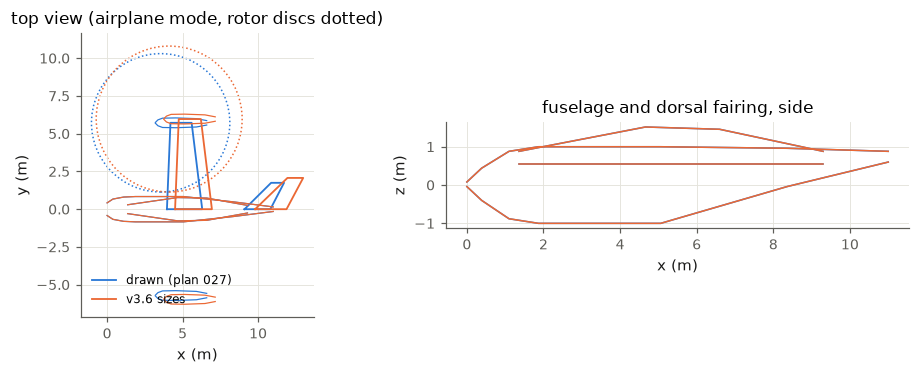

AeroSandbox twin: wings ['wing', 'v_tail'], bodies ['fuselage', 'wing_fairing', 'nacelle_right', 'nacelle_left']; s_ref 21.388 -> 23.299 m2, fuselage wetted 50.3 m2
PASS  a v3.6 snapshot built with replace() carries the baseline wing area


In [12]:
span, area = reference["span_wing_m"], reference["area_wing_m2"]
chord_root = 2 * area / (span * 1.6)
x_qc = reference["x_le_wing_m"] + 0.25 * area / span
snapshot_v36 = replace(snapshot,
    wing=replace(w, span_m=span, chord_root_m=chord_root, chord_tip_m=0.6 * chord_root, x_le_root_m=x_qc - 0.25 * chord_root),
    rotor=RotorSnapshot(radius_m=reference["radius_rotor_m"], count_blades=assumptions.count_blades,
                        solidity=float(ref.design.solidity)),
    v_tail=v_tail_equivalent(reference["area_horizontal_tail_m2"], reference["area_vertical_tail_m2"], aspect_ratio=3.27,
                             taper_ratio=0.5, sweep_le_deg=40.0, x_le_root_m=assumptions.x_horizontal_tail_m, z_m=0.85,
                             thickness_to_chord=0.12))
fig, (ax_top, ax_side) = plt.subplots(1, 2, figsize=(9, 3.5))
for snap, colour, label in ((snapshot, blue, "drawn (plan 027)"), (snapshot_v36, orange, "v3.6 sizes")):
    airplane = snap.to_asb()
    for wing_ in airplane.wings:
        le, te = [], []
        for xs in wing_.xsecs:
            le.append((xs.xyz_le[0], xs.xyz_le[1])); te.append((xs.xyz_le[0] + xs.chord, xs.xyz_le[1]))
        outline = np.array(le + te[::-1] + le[:1])
        ax_top.plot(outline[:, 0], outline[:, 1], color=colour, lw=1.2, label=label if wing_.name == "wing" else None)
    for body in airplane.fuselages:
        x = [xs.xyz_c[0] for xs in body.xsecs]
        y = [xs.xyz_c[1] for xs in body.xsecs]
        half_w = [xs.width / 2 for xs in body.xsecs]
        ax_top.plot(x, np.array(y) + half_w, color=colour, lw=0.8); ax_top.plot(x, np.array(y) - half_w, color=colour, lw=0.8)
        if body.name in ("fuselage", "wing_fairing"):
            z = np.array([xs.xyz_c[2] for xs in body.xsecs]); half_h = np.array([xs.height / 2 for xs in body.xsecs])
            ax_side.plot(x, z + half_h, color=colour, lw=1); ax_side.plot(x, z - half_h, color=colour, lw=1)
    xs_, ys_, zs_ = snap.spindle_xyz_m()
    ax_top.add_patch(plt.Circle((xs_ - snap.nacelle.length_mast_m, ys_), snap.rotor.radius_m, fill=False, color=colour, ls=":"))
ax_top.set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="top view (airplane mode, rotor discs dotted)")
ax_side.set(aspect="equal", xlabel="x (m)", ylabel="z (m)", title="fuselage and dorsal fairing, side")
ax_top.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()
a_draw, a_v36 = snapshot.to_asb(), snapshot_v36.to_asb()
print(f"AeroSandbox twin: wings {[x.name for x in a_draw.wings]}, bodies {[x.name for x in a_draw.fuselages]}; "
      f"s_ref {a_draw.s_ref:.3f} -> {a_v36.s_ref:.3f} m2, fuselage wetted {a_draw.fuselages[0].area_wetted():.1f} m2")
check("a v3.6 snapshot built with replace() carries the baseline wing area", abs(a_v36.s_ref - area) < 1e-9)

**Is the snapshot really numeric-only?** Decision 031 ("Symbolic considerations") says "`GeometrySnapshot` refuses
CasADi inputs". There is no such check in `snapshot.py`: the dataclasses accept anything. Try it.

In [13]:
opti = asb.Opti()
span_variable = opti.variable(init_guess=11.0)
symbolic_wing = replace(w, span_m=span_variable)          # accepted without complaint
print(type(symbolic_wing.span_m).__name__, "->", type(symbolic_wing.x_le_tip_m()).__name__)
check("SurfaceSnapshot silently accepts a CasADi variable (no refusal as decision 031 specified)",
      type(symbolic_wing.span_m).__name__ == "MX")

MX -> MX
PASS  SurfaceSnapshot silently accepts a CasADi variable (no refusal as decision 031 specified)


Nothing breaks until an OpenVSP call receives the `MX` (a SWIG type error). In practice the risk is small because
the only factory types floats in, but the documented guard does not exist. (Findings.)

---
## 2. `model.py`: the OpenVSP outer mold line

In [14]:
show_source("src/aircraft_closure/export/openvsp/model.py", 1, 69)

# src/aircraft_closure/export/openvsp/model.py  lines 1-69
   1  """OpenVSP outer mold line of a tiltrotor from a numeric `GeometrySnapshot`.
   2  
   3  The model tree follows the author-supplied tiltrotor skeleton (plan 031):
   4  
   5      Fuselage (smoothly skinned Fuselage geom)
   6      |- WingFairing (dorsal fairing, optional)
   7      |- Wing
   8      |  `- NacelleTilt (Hinge about y at the conversion spindle)
   9      |     `- Nacelle (Fuselage geom)
  10      |        `- Rotor (Propeller)
  11      |           `- RotorTipPath (Auxiliary)
  12      `- HorizontalTail and VerticalTail, or VTail
  13  
  14  Units are metres. OpenVSP is imported here only; nothing in `vehicle/` or the
  15  sizing code imports this module.
  16  """
  17  import math
  18  
  19  import openvsp as vsp
  20  
  21  from aircraft_closure.export.openvsp.snapshot import BodySnapshot
  22  
  23  # Propeller blade curve indices (OpenVSP 3.53.1): chord c/R and twist in degrees over r/R.
  24  _p

- **L1-16 docstring.** The model tree, patterned on the author's V-22 skeleton file (decision 031): Fuselage with
  children WingFairing, Wing, tails; Wing → NacelleTilt (a Hinge) → Nacelle → Rotor → RotorTipPath. L14-15 restate
  the rule of section 0.
- **L17-21.** `import openvsp as vsp` at module level: importing `model` without OpenVSP fails immediately. That is
  acceptable only because no sizing code imports it.
- **L23-25.** OpenVSP propeller blade curve indices (3.53.1): curve 0 is chord c/R, curve 1 twist in degrees.
- **L28-30 `_set`.** `SetParmVal(geom, name, group, value)`; OpenVSP returns the value set or 0 and does not raise
  on a misspelled name. The code raises `KeyError` only when the parameter really does not exist
  (`FindParm == ""`), so a legitimate 0 result does not trip it. Silent typos were the failure mode this guards.
- **L33-37 `_set_xsec`.** Same idea for cross-section parameters, via `GetXSecParm`.
- **L40-45 `_attach_to_parent`.** Translation and rotation attached to the parent component, then a relative offset.
  Used for the hinge children: they move when the hinge rotates.
- **L48-55 `_place_absolute`.** No attachment: the "relative" location is then absolute. Optional rotation about x
  (90 deg turns a wing into a fin).
- **L58-69 `_slope_deg`.** Tangent angle of a station profile. Inside, a weighted central difference with the
  slopes before (s₋) and after (s₊) and the gaps Δx₋, Δx₊:

$$s_i = \frac{s_-\,\Delta x_+ + s_+\,\Delta x_-}{\Delta x_- + \Delta x_+}$$

  This is the exact derivative at the middle point of the parabola through the three points, so it is exact for a
  quadratic profile even on uneven spacing. One-sided differences at the ends. Returned as degrees, which is what
  `SetXSecTanAngles` takes.

In [15]:
from aircraft_closure.export.openvsp import model as vsp_model
x = [0.0, 0.3, 1.0, 1.4]
quad = [2 * xi**2 - xi + 0.5 for xi in x]                  # derivative 4x - 1
slopes = [vsp_model._slope_deg(x, quad, i) for i in (1, 2)]
exact = [math.degrees(math.atan(4 * xi - 1)) for xi in (0.3, 1.0)]
print("weighted central difference", [round(s, 6) for s in slopes], "exact", [round(e, 6) for e in exact])
check("_slope_deg is exact for a quadratic on uneven spacing", np.allclose(slopes, exact, atol=1e-12))

weighted central difference [11.309932, 71.565051] exact [11.309932, 71.565051]
PASS  _slope_deg is exact for a quadratic on uneven spacing


In [16]:
show_source("src/aircraft_closure/export/openvsp/model.py", 72, 141)

# src/aircraft_closure/export/openvsp/model.py  lines 72-141
  72  def _add_body(name, body, parent_id=None, tessellation_section=6):
  73      """Smoothly skinned body (OpenVSP Fuselage geom, super-ellipse sections) with round end caps.
  74  
  75      Each section's skinning tangents follow the local slopes of the top line,
  76      bottom line and half-width line (positive opens outward), so the surface
  77      flows through the stations instead of flattening at each one.
  78      """
  79      stations = body.stations
  80      geom_id = vsp.AddGeom("FUSELAGE", parent_id) if parent_id else vsp.AddGeom("FUSELAGE")
  81      vsp.SetGeomName(geom_id, name)
  82      x_m = [station.x_m for station in stations]
  83      length_m = x_m[-1] - x_m[0]
  84      _set(geom_id, "Length", "Design", length_m)
  85      surface_id = vsp.GetXSecSurf(geom_id, 0)
  86      while vsp.GetNumXSec(surface_id) > len(stations):
  87          vsp.CutXSec(geom_id, vsp.GetNumXSec(surface_id) - 2)
  88 

**L72-119 `_add_body`**, one smoothly skinned body (an OpenVSP "FUSELAGE" geom with super-ellipse sections):

- **L80-84:** add the geom (as a child when `parent_id` is given), name it, set the length to the station span.
- **L85-89:** make the cross-section count equal the station count. A new OpenVSP fuselage has 5 sections; sections
  are cut or inserted at index n − 2, so the two end caps stay at the ends.
- **L90-92:** three profile lines: top z, bottom z with its sign flipped (so "positive opens outward" for both top
  and bottom tangents, L75-76), and half width.
- **L93-98:** positions as fractions of length (`XLocPercent`) and z offsets relative to the first station, also
  divided by length (`ZLocPercent`). OpenVSP clamps each section between its neighbours, so a single pass can be
  rejected when a section has to move past where its neighbour still sits; three sweeps settle it.
- **L99-114 per section:** super-ellipse shape, top/bottom symmetry off (`Super_TopBotSym 0`) so `Super_M_bot`,
  `Super_N_bot` take the bottom exponent, width, height, tessellation 6 per segment. Tangent symmetry flags: not all
  equal, not top-bottom equal, left-right equal (`RLSym 1`). `SetXSecTanAngles(both sides, top, right, bottom, left)`
  sets the skinning tangent of each side to the local slope of its profile line: this is the "blending pass" of
  decision 031 (2026-10-04); OpenVSP's default horizontal tangents made the bodies look segmented.
- **L115-118:** round end caps, 41 circumferential lines, placed at (x_nose + x₀, 0, z₀) absolute.

**L122-141 `_add_surface`**: a "WING" geom placed at the root LE (rotated 90 deg about x for a fin), XZ symmetry
for symmetric surfaces, then the outer section `XSec_1`: span *per panel* (half the tip-to-tip span, L128), root and
tip chords, sweep and its chord station, dihedral, 12 spanwise lines. Every section becomes a NACA 4-series with
the snapshot's t/c, camber and camber location. OpenVSP's "Span" is measured along the dihedral line, which matches
the snapshot's "span along the panels".

In [17]:
show_source("src/aircraft_closure/export/openvsp/model.py", 144, 183)

# src/aircraft_closure/export/openvsp/model.py  lines 144-183
 144  def _add_nacelle_group(snapshot, wing_id, angle_nacelle_deg):
 145      n, r = snapshot.nacelle, snapshot.rotor
 146      x_spindle_m, y_spindle_m, z_spindle_m = snapshot.spindle_xyz_m()
 147  
 148      hinge_id = vsp.AddGeom("HINGE", wing_id)
 149      vsp.SetGeomName(hinge_id, "NacelleTilt")
 150      _place_absolute(hinge_id, x_spindle_m, y_spindle_m, z_spindle_m)
 151      # Hinge axis along +y, as in the skeleton (primary direction y, secondary z).
 152      for name_parm, value in (("PrimaryDir", 1), ("SecondaryDir", 2), ("PrimXVec", 0.0), ("PrimYVec", 1.0),
 153                               ("PrimZVec", 0.0), ("JointRotateFlag", 1)):
 154          _set(hinge_id, name_parm, "Hinge", value)
 155      _set(hinge_id, "JointRotate", "Hinge", angle_nacelle_deg)
 156  
 157      nacelle_id = _add_body("Nacelle", BodySnapshot(stations=n.stations()), hinge_id)
 158      _attach_to_parent(nacelle_id, x_rel_m=-n.length_m

**L144-183 `_add_nacelle_group`**, the tilting part:

- **L148-155 hinge.** A Hinge geom under the wing, placed at the spindle. Primary direction y (`PrimaryDir 1`,
  vector (0, 1, 0)), secondary z; `JointRotateFlag 1` enables rotation; `JointRotate` = nacelle angle in degrees.
- **L157-158 nacelle.** The airplane-mode body (`n.stations()`) attached to the hinge at x_rel = −(mast + nose
  offset): spinner tip 1.35 m ahead of the spindle along the nacelle axis. When the hinge rotates 90 deg, that axis
  points up and the spinner is above the spindle.
- **L160-166 rotor.** A "PROP" child of the nacelle at x_rel = nose offset, i.e. at the hub. Diameter 2R, blades,
  precone, `Beta34` = collective at 0.75 R.
- **L167-173 blade curves.** Constant chord c/R = σ π / B, which inverts σ = B c / (π R). Twist is linear through
  zero at 0.75 R: θ(r/R) = θ_tw (r/R − 0.75) / (1 − 0.2), so θ(1) − θ(0.2) = θ_tw. With θ_tw = −40 deg that is
  +27.5 deg at the root and −12.5 deg at the tip.
- **L175-178 tip path.** An Auxiliary "rotor tip path" geom (the clearance disc) attached to the rotor.
- **L179-182 symmetry.** A Hinge has no surface, so mirroring it does nothing for its children (decision 031
  progress); each child is mirrored itself about the global XZ plane (`Sym_Ancestor 0`).

In [18]:
show_source("src/aircraft_closure/export/openvsp/model.py", 186, 268)

# src/aircraft_closure/export/openvsp/model.py  lines 186-268
 186  # User sets: the wetted outer mold line (exports, CompGeom), clearance envelopes (checks only), and the
 187  # airframe / rotor split of the outer mold line (renders).
 188  set_outer_mold_line = vsp.SET_FIRST_USER
 189  set_clearance = vsp.SET_FIRST_USER + 1
 190  set_airframe = vsp.SET_FIRST_USER + 2
 191  set_rotors = vsp.SET_FIRST_USER + 3
 192  
 193  
 194  def build_openvsp_model(snapshot, angle_nacelle_deg=90.0):
 195      """Clear the OpenVSP model and build the outer mold line; returns {name: geom id}."""
 196      vsp.VSPRenew()
 197      vsp.SetSetName(set_outer_mold_line, "OuterMoldLine")
 198      vsp.SetSetName(set_clearance, "Clearance")
 199      vsp.SetSetName(set_airframe, "Airframe")
 200      vsp.SetSetName(set_rotors, "Rotors")
 201      fuselage_id = _add_body("Fuselage", snapshot.fuselage)
 202      wing_id = _add_surface("Wing", snapshot.wing, fuselage_id)
 203      geoms = dict(Fuselage=fusel

- **L186-191 sets.** Four user sets: `OuterMoldLine` (exports, CompGeom), `Clearance` (the tip-path discs only, for
  checks), `Airframe` and `Rotors` (the split used by the renders so rotors draw dark). `SET_FIRST_USER` is 3.
- **L194-221 `build_openvsp_model`.** `VSPRenew` clears the model (every call is a fresh model). Add fuselage, wing
  (child of the fuselage), optional fairing and tails, then the nacelle group (L213). Set flags (L214-219): the tip
  path only in `Clearance`; the hinge in no set (no surface); everything else in `OuterMoldLine` and in exactly one of
  `Rotors` / `Airframe`. `vsp.Update()` once at the end. Returns {name: geom id}.
- **L224-239 Modes.** A variable-preset group "NacelleAngle" holding the hinge's `JointRotate`, one setting per mode
  (hover 90, conversion 45, cruise 0), each wrapped in an OpenVSP Mode for the GUI.
- **L242-268 `export_outer_mold_line`.** Per angle, a **fresh build** (L255). The docstring (L245-247) records why:
  OpenVSP 3.53.1 keeps the first export's tessellation of hinge children when only the hinge angle changes, even
  through Modes. Four files per angle (L257-263): whole OML STL and STEP, airframe STL, rotors STL. Tag
  `{angle:02.0f}` gives `halo_nacelle90`, `45`, `00`. Finally a hover build with Modes is saved as `.vsp3`.

**Run it** with the stand-in: the model tree, the hinge and blade numbers, set membership and the file list.

In [19]:
geoms = vsp_model.build_openvsp_model(snapshot, angle_nacelle_deg=90.0)
for name, geom_id in geoms.items():
    parent = vsp.geoms[geom_id]["parent"]
    print(f"{name:<14} {vsp.geoms[geom_id]['kind']:<10} parent: {vsp.geoms[parent]['name'] if parent else '-'}")
print("API calls recorded:", len(vsp.calls))
hinge = [vsp.parm("NacelleTilt", "XForm", k) for k in ("X_Rel_Location", "Y_Rel_Location", "Z_Rel_Location")]
print("hinge at", [round(v, 4) for v in hinge], "JointRotate", vsp.parm("NacelleTilt", "Hinge", "JointRotate"),
      "| nacelle x_rel", vsp.parm("Nacelle", "XForm", "X_Rel_Location"), "| rotor x_rel", vsp.parm("Rotor", "XForm", "X_Rel_Location"))
pcurves = [args for name, args in vsp.calls if name == "SetPCurve"]
for _, index, r_over_R, values, _ in pcurves:
    print(f"pcurve {index}: r/R {r_over_R} -> {[round(v, 5) for v in values]}")
print("xsec counts: fuselage", vsp.xsecs[geoms["Fuselage"]], "| nacelle", vsp.xsecs[geoms["Nacelle"]],
      "| fairing", vsp.xsecs[geoms["WingFairing"]])
for index, label in ((vsp_model.set_outer_mold_line, "OuterMoldLine"), (vsp_model.set_clearance, "Clearance"),
                     (vsp_model.set_airframe, "Airframe"), (vsp_model.set_rotors, "Rotors")):
    print(f"set {index} {label:<14}{vsp.set_names(index)}")
check("hinge sits at the snapshot spindle", np.allclose(hinge, snapshot.spindle_xyz_m(), atol=1e-12))
check("blade chord c/R = sigma pi / B and twist tip minus root = -40 deg",
      abs(pcurves[0][3][0] - 0.089 * math.pi / 3) < 1e-12 and abs(pcurves[1][3][-1] - pcurves[1][3][0] + 40.0) < 1e-12)
check("cross-section counts match the station counts (7 fuselage, 6 nacelle, 4 fairing)",
      (vsp.xsecs[geoms["Fuselage"]], vsp.xsecs[geoms["Nacelle"]], vsp.xsecs[geoms["WingFairing"]]) == (7, 6, 4))
with tempfile.TemporaryDirectory() as directory:
    paths = vsp_model.export_outer_mold_line(snapshot, directory)
print("files that would be written:", sorted(Path(p).name for p in paths.values()))

Fuselage       FUSELAGE   parent: -
Wing           WING       parent: Fuselage
WingFairing    FUSELAGE   parent: Fuselage
VTail          WING       parent: Fuselage
NacelleTilt    HINGE      parent: Wing
Nacelle        FUSELAGE   parent: NacelleTilt
Rotor          PROP       parent: Nacelle
RotorTipPath   AUXILIARY  parent: Rotor
API calls recorded: 453
hinge at [4.5464, 5.7205, 1.2] JointRotate 90.0 | nacelle x_rel -1.35 | rotor x_rel 0.35
pcurve 0: r/R [0.2, 1.0] -> [0.0932, 0.0932]
pcurve 1: r/R [0.2, 0.75, 1.0] -> [27.5, -0.0, -12.5]
xsec counts: fuselage 7 | nacelle 6 | fairing 4
set 3 OuterMoldLine ['Fuselage', 'Nacelle', 'Rotor', 'VTail', 'Wing', 'WingFairing']
set 4 Clearance     ['RotorTipPath']
set 5 Airframe      ['Fuselage', 'Nacelle', 'VTail', 'Wing', 'WingFairing']
set 6 Rotors        ['Rotor']
PASS  hinge sits at the snapshot spindle
PASS  blade chord c/R = sigma pi / B and twist tip minus root = -40 deg
PASS  cross-section counts match the station counts (7 fuselage, 6 

---
## 3. `render.py`: PyVista renders (not run here)

In [20]:
show_source("src/aircraft_closure/export/openvsp/render.py", 1, 57)

# src/aircraft_closure/export/openvsp/render.py  lines 1-57
   1  """Off-screen renders of OpenVSP STL exports with PyVista (the optional `geometry` dependency group).
   2  
   3  Axes follow AeroSandbox (x aft, y right, z up). Views put the nose to the
   4  viewer's left; the perspective view looks from ahead, left and above.
   5  """
   6  import numpy as np
   7  import pyvista as pv
   8  
   9  colour_airframe = "#dfe3e8"
  10  colour_rotors = "#30343b"
  11  colour_background = "white"
  12  
  13  # (title, camera direction from the aircraft centre, view-up vector, orthographic)
  14  views_perspective = ("perspective", (-1.0, -1.15, 0.7), (0.0, 0.0, 1.0), False)
  15  views_orthographic = (("side", (0.0, -1.0, 0.0), (0.0, 0.0, 1.0), True),
  16                        ("top", (0.0, 0.0, 1.0), (0.0, 1.0, 0.0), True),
  17                        ("front", (-1.0, 0.0, 0.0), (0.0, 0.0, 1.0), True))
  18  
  19  
  20  def _read_mesh(path):
  21      mesh = pv.read(str(path)).clea

- **L1-11.** PyVista is the optional `geometry` dependency group (decision 031, second shape pass). Colours: light
  airframe, dark rotors, white background.
- **L13-17 views.** (title, camera direction from the aircraft centre, view-up, orthographic). Perspective from
  ahead-left-above (−1, −1.15, 0.7); side from −y, top from +z with +y up on screen, front from −x.
- **L20-22 `_read_mesh`.** Read, merge duplicate points (`clean`), split normals at 40 deg so creases stay sharp
  under smooth shading. `auto_orient_normals=False`: OpenVSP's STL winding is trusted.
- **L25-29.** Airframe and rotors as two meshes with their own colours (why the export writes them separately).
- **L32-41 `_set_camera`.** Centre of the bounds; camera 2.5 largest extents away along the view direction;
  parallel projection for the orthographic views; reset then zoom.
- **L44-56 `render_sheet`.** A grid of subplots, one per view row, off-screen, anti-aliased, saved as PNG.

In [21]:
show_source("src/aircraft_closure/export/openvsp/render.py", 59, 132)

# src/aircraft_closure/export/openvsp/render.py  lines 59-132
  59  def read_stl_solids(path):
  60      """{solid name: PolyData} of an ASCII STL with named solids (OpenVSP FEA exports one solid per part)."""
  61      solids, name, vertices = {}, None, []
  62      with open(path) as file:
  63          for line in file:
  64              words = line.split()
  65              if not words:
  66                  continue
  67              if words[0] == "solid":
  68                  name, vertices = (words[1] if len(words) > 1 else "solid"), []
  69              elif words[0] == "vertex":
  70                  vertices.append([float(value) for value in words[1:4]])
  71              elif words[0] == "endsolid" and vertices:
  72                  points = np.array(vertices)
  73                  faces = np.hstack([np.full((len(points) // 3, 1), 3), np.arange(len(points)).reshape(-1, 3)])
  74                  solids[name] = pv.PolyData(points, faces.ravel()).clean()
  75      return 

- **L59-75 `read_stl_solids`.** A hand-written ASCII STL reader that keeps the solid names (OpenVSP FEA writes one
  solid per part), building PyVista triangles `[3, i, j, k]`. `structure_check.stl_solid_areas_m2` (section 5)
  parses the same format again, for areas, without PyVista: two parsers of one format.
- **L78-81.** Part-family colours, matched by substring *in order*: "FrontSparBulkhead" contains "Spar", so
  "Bulkhead" is listed first.
- **L84-95 `_ring_frames`.** Ring frames are beam elements, which the STL does not contain; they are drawn by
  slicing the fuselage skin at each frame station and making a 25 mm tube of the cut.
- **L98-132 `render_structure`.** Two views; the outer mold line at 12 % opacity with depth peeling (L128) so it
  does not hide what is inside; skins skipped; shell "Frames" skipped when ring frames are drawn; each part coloured
  by family, grey otherwise.

In [22]:
from aircraft_closure.export.openvsp import render
parts = ["FrontSparBulkhead", "FrontSpar", "Ribs", "NacelleRib", "Frames", "Floor", "Skin"]
family = {p: next((f for f, _ in render.colours_structure if f in p), "grey") for p in parts}
print(family)
check("first-match order makes FrontSparBulkhead a bulkhead, not a spar", family["FrontSparBulkhead"] == "Bulkhead")

{'FrontSparBulkhead': 'Bulkhead', 'FrontSpar': 'Spar', 'Ribs': 'Rib', 'NacelleRib': 'Rib', 'Frames': 'Frame', 'Floor': 'Floor', 'Skin': 'grey'}
PASS  first-match order makes FrontSparBulkhead a bulkhead, not a spar


---
## 4. `structure.py`: OpenVSP FEA structures

In [23]:
show_source("src/aircraft_closure/export/openvsp/structure.py", 1, 92)

# src/aircraft_closure/export/openvsp/structure.py  lines 1-92
   1  """OpenVSP internal structure (FEA structures) of a `GeometrySnapshot`, meshed and exported (plan 031, milestone C).
   2  
   3  Structures remain mass estimation in this framework; this layout is for CAD
   4  (STEP), for later finite-element checks (CalculiX / Nastran decks) and for
   5  packaging. Nothing here feeds the sizing.
   6  
   7  Layout (first pass, placeholder gauges):
   8  - Wing (right half; the left is its mirror): front and rear spars, a rib
   9    array, attach ribs at the dorsal-fairing sides and a nacelle rib at the
  10    spindle, upper and lower skins.
  11  - Fuselage: 0.6 m ring frames (I-section beams along the skin), bulkheads at the nose bay, both wing-spar stations
  12    and the cabin end, a cabin floor, skin.
  13  - V-tail (one panel): two spars and a rib array, skin.
  14  """
  15  from dataclasses import dataclass
  16  from pathlib import Path
  17  
  18  import openvsp as v

- **L1-14 docstring.** Structures stay a mass estimate (L3-5); this layout serves CAD, FE decks and packaging, and
  "Nothing here feeds the sizing". The layout list is the plan 031 milestone C.
- **L23-41 `StructureLayout`.** Spars at 0.15 and 0.60 chord (the same fractions plan 038 uses for the AFDD cap
  depth κ = 0.826), 0.5 m wing rib pitch, 0.6 m frame pitch, floor 0.35 m above the bottom, nose bulkhead at 1.6 m,
  cabin end at 5.06 m, tail rib pitch 0.4 m. Gauges (L34-38) are placeholders "until the AFDD wing masses are
  mapped"; that mapping was later done in `fe_wing.py`, not here. Ring frames: I-section 75 x 30 x 1.6 mm.
- **L44-48 `_parm`.** Find-then-set with a `KeyError` on a missing name.
- **L51-56 `_material`, L59-63 `_property`.** Add an FEA material (density, E, ν) or a shell property (material
  index, thickness) and return its *index*, which is what parts reference. Both take a `name` argument and **never
  use it**: the materials and properties appear in OpenVSP under default names. (Findings.)
- **L66-74 `_beam_property_i_section`.** A beam property with an I cross-section; Dim1-6 follow Nastran PBARL "I":
  depth, two flange widths, web thickness, two flange thicknesses (all one gauge here).
- **L77-85 `_part`.** Add a part, name it, default to shell elements and a property, then apply keyword parameters
  written `Group__Name` (split at the double underscore). Keyword parameters come last, so a caller's
  `FeaPart__IncludedElements=FEA_BEAM` (L142) overrides the shell default at L80.
- **L88-92 `_skin`.** A structure created with a skin has it as part 0; set its property.

In [24]:
show_source("src/aircraft_closure/export/openvsp/structure.py", 95, 197)

# src/aircraft_closure/export/openvsp/structure.py  lines 95-197
  95  def build_structure(snapshot, layout=StructureLayout()):
  96      """Build the outer mold line (airplane mode) and its FEA structures; returns (geoms, {name: struct id})."""
  97      geoms = build_openvsp_model(snapshot, 0.0)
  98      vehicle_id = vsp.FindContainer("Vehicle", 0)
  99      vsp.SetParmVal(vsp.FindParm(vehicle_id, "StructUnit", "FeaStructure"), vsp.SI_UNIT)
 100      # Placeholder materials: quasi-isotropic carbon for the lifting surfaces, 7075 aluminium for the fuselage.
 101      carbon = _material("CarbonQuasiIsotropic", 1600.0, 60e9, 0.30)
 102      aluminium = _material("Aluminium7075", 2810.0, 71.7e9, 0.33)
 103      skin_carbon = _property("SkinCarbon", carbon, layout.thickness_skin_m)
 104      web = _property("SparWeb", carbon, layout.thickness_spar_web_m)
 105      rib = _property("Rib", carbon, layout.thickness_rib_m)
 106      skin_aluminium = _property("SkinAluminium", aluminium, layout

**L95-166 `build_structure`.**

- **L97-99:** airplane-mode outer mold line (0 deg), SI units for the FEA.
- **L100-110:** two placeholder materials, quasi-isotropic carbon (1600 kg/m³, 60 GPa, 0.30) and 7075 aluminium
  (2810, 71.7 GPa, 0.33); five shell properties and the I-beam property.
- **L113-130 wing box (right half; OpenVSP structures one surface, the mirror is meshed with it):** carbon skin, two
  spars at the layout fractions (`RelCenterLocation` along the chord), a rib array at 0.5 m absolute spacing over
  the whole span, a fairing-attach rib at half the widest fairing station (L124-127) and a nacelle rib half a
  nacelle width inboard of the tip (L128-129). The nacelle rib is what `fe_wing` later finds by name to attach the
  rigid tip body.
- **L133-152 fuselage:** aluminium skin; ring frames as a slice array of y-z planes from 0.6 m to L − 0.3 m at 0.6 m,
  beam elements only, with the I-section as cap property (L139-142); four full bulkheads (nose 1.6 m, both root spar
  stations, cabin end 5.06 m) as y-z slices; the floor as an x-y slice 0.35 m above the bottom.
- **L155-164 V-tail:** one panel, spars at 0.20 and 0.65 chord, ribs at 0.4 m.

**L169-197 `export_structure_meshes`.** Per structure: max and min edge length (0.15 and 0.03 m), a file name per
requested kind, then one `ComputeFeaMesh` **per kind** (L195-196). The docstring records the OpenVSP 3.53.1
behaviour: one file type per call, a re-mesh each time, the `FeaMeshAnalysis` wrapper never finished, the
structural STEP stalled. The fuselage takes minutes per kind, so callers ask only for what they need
(`halo_wing_fe.py` asks for `calculix` only).

**Run it.** Note the bulkhead stations printed below: the cabin-end bulkhead (5.06 m, a fixed layout field) falls
between the two wing-spar bulkheads (4.31 and 5.36 m on the drawn wing), 0.3 m ahead of the rear-spar bulkhead.
The 5.06 m is "0.46 of the 11 m fuselage", tied to the fuselage profile, not to the wing position. (Findings.)

In [25]:
from aircraft_closure.export.openvsp.structure import StructureLayout, build_structure, export_structure_meshes
layout = StructureLayout()
geoms_s, structures = build_structure(snapshot, layout)
for (geom_id, index), struct in vsp.structs.items():
    print(f"{struct['name']:<9}", [(vsp.parts[p]["name"], vsp.parts[p]["kind"].replace("FEA_", "")) for p in struct["parts"]])
loc = lambda name: [v for k, v in vsp.parms.items() if k.endswith(":FeaPart:AbsCenterLocation") and vsp.parts.get(k.rsplit(":", 2)[0], {}).get("name") == name]
print(f"FairingAttachRib at y = {loc('FairingAttachRib')[0]:.3f} m, NacelleRib at y = {loc('NacelleRib')[0]:.3f} m "
      f"(semispan {snapshot.wing.span_m/2:.3f} m)")
print("bulkheads x (m):", {n: round(loc(n)[0], 3) for n in ("NoseBulkhead", "FrontSparBulkhead", "RearSparBulkhead", "CabinEndBulkhead")})
length_fuselage_m = snapshot.fuselage.stations[-1].x_m
frames = np.arange(layout.pitch_frame_m, length_fuselage_m - 0.3 + 1e-9, layout.pitch_frame_m)
print(f"ring frames: {len(frames)} from {frames[0]:.1f} to {frames[-1]:.1f} m; materials {len(vsp.materials)}, properties {len(vsp.properties)}")
check("17 ring frames at 0.6 m pitch on the 11 m fuselage (decision 031: '17 ring frames')", len(frames) == 17)
frame_part = next(p for p, d in vsp.parts.items() if d["name"] == "Frames")
check("the Frames keyword FEA_BEAM overrides the shell default set first",
      vsp.parms[f"{frame_part}:FeaPart:IncludedElements"] == "FEA_BEAM")
with tempfile.TemporaryDirectory() as directory:
    mesh_paths = export_structure_meshes(structures, directory, kinds=("calculix", "stl"))
    print({k: Path(v).name for k, v in mesh_paths.items()})
print("ComputeFeaMesh calls:", [(vsp.geoms[a[0]]["name"], a[2]) for n, a in vsp.calls if n == "ComputeFeaMesh"])

WingBox   [('Skin', 'SKIN'), ('FrontSpar', 'SPAR'), ('RearSpar', 'SPAR'), ('Ribs', 'RIB_ARRAY'), ('FairingAttachRib', 'RIB'), ('NacelleRib', 'RIB')]
Fuselage  [('Skin', 'SKIN'), ('Frames', 'SLICE_ARRAY'), ('NoseBulkhead', 'SLICE'), ('FrontSparBulkhead', 'SLICE'), ('RearSparBulkhead', 'SLICE'), ('CabinEndBulkhead', 'SLICE'), ('Floor', 'SLICE')]
VTail     [('Skin', 'SKIN'), ('FrontSpar', 'SPAR'), ('RearSpar', 'SPAR'), ('Ribs', 'RIB_ARRAY')]
FairingAttachRib at y = 0.771 m, NacelleRib at y = 5.396 m (semispan 5.721 m)
bulkheads x (m): {'NoseBulkhead': 1.6, 'FrontSparBulkhead': 4.313, 'RearSparBulkhead': 5.364, 'CabinEndBulkhead': 5.06}
ring frames: 17 from 0.6 to 10.2 m; materials 2, properties 7
PASS  17 ring frames at 0.6 m pitch on the 11 m fuselage (decision 031: '17 ring frames')
PASS  the Frames keyword FEA_BEAM overrides the shell default set first
{('WingBox', 'stl'): 'WingBox.stl', ('WingBox', 'calculix'): 'WingBox.inp', ('Fuselage', 'stl'): 'Fuselage.stl', ('Fuselage', 'calculix

---
## 5. `structure_check.py`: layout-based primary structure (closed form)

Pure Python and NumPy; nothing here needs OpenVSP except the part areas, which are read from its STL.

In [26]:
show_source("src/aircraft_closure/export/openvsp/structure_check.py", 1, 53)

# src/aircraft_closure/export/openvsp/structure_check.py  lines 1-53
   1  """Layout-based primary-structure masses: a back-check of the sizing's weight correlations (plan 031).
   2  
   3  The sizing weighs the wing with the AFDD tiltrotor model (torque box from the
   4  torsion frequency, spar caps from the bending frequencies and the jump
   5  take-off, a uniform idealized section) and the tails and fuselage with Raymer's
   6  general-aviation correlations. This module weighs the same primary structure
   7  from the drawn layout instead: the real tapered box between the layout's spars
   8  with the airfoil's depth at each spar, spanwise bending-moment distributions,
   9  and the OpenVSP structure's part areas. Gauges come from simple, stated
  10  criteria (strength, stiffness, minimum gauge); nothing here feeds the sizing.
  11  
  12  First-order methods throughout; every assumption is a field or a docstring.
  13  """
  14  from dataclasses import dataclass
  15  
  16  im

- **L1-12 docstring.** The point of the module: weigh the same primary structure the sizing weighs (AFDD wing,
  Raymer tails and fuselage), but from the drawn layout: the real two-spar box with the airfoil depth at each spar,
  spanwise moment distributions, and OpenVSP part areas. Gauges come from strength, stiffness or minimum gauge.
- **L18 `g_m_s2`** is defined and never used in this module (the example uses its own 9.80665 literals). (Findings.)
- **L23-28 `naca_four_digit_thickness`.** The NACA 4-digit half-thickness is
  y_t = 5 t (0.2969 √x − 0.1260 x − 0.3516 x² + 0.2843 x³ − 0.1015 x⁴); the function returns the *full* thickness
  over chord, hence the factor 10 (L26 comment). This is the thickness distribution only; camber shifts the section,
  not its depth (to first order).
- **L31-47 `stl_solid_areas_m2`.** Same STL parser as `render.read_stl_solids`, summing ½ |(b − a) × (c − a)| per
  triangle per named solid. Areas of the same name accumulate (mirrored sides).
- **L50-52 `area_by_part_m2`.** Sum over solids whose name starts with a prefix ("Ribs", "Skin", ...).

In [27]:
from aircraft_closure.export.openvsp import structure_check as sc
thickness_front, thickness_rear = sc.naca_four_digit_thickness([0.15, 0.60], 0.23)
airfoil = asb.Airfoil("naca2423")
kappa = 0.5 * (thickness_front + thickness_rear) / 0.23
print(f"depth/chord at 0.15 c {thickness_front:.4f} (AeroSandbox {float(airfoil.local_thickness(0.15)):.4f}), "
      f"at 0.60 c {thickness_rear:.4f} (AeroSandbox {float(airfoil.local_thickness(0.60)):.4f}); "
      f"mean / t {kappa:.3f} vs sizing kappa {reference['ratio_depth_spar_cap']:.3f}")
check("closed-form box depth ratio equals the plan 038 kappa used by the sizing (to 1 %)",
      abs(kappa / reference["ratio_depth_spar_cap"] - 1) < 0.01)
stl = '''solid FrontSpar
 facet normal 0 0 1
  outer loop
   vertex 0 0 0
   vertex 2 0 0
   vertex 0 3 0
  endloop
 endfacet
endsolid FrontSpar
solid FrontSpar
 facet normal 0 0 1
  outer loop
   vertex 0 0 0
   vertex 1 0 0
   vertex 0 1 0
  endloop
 endfacet
endsolid FrontSpar
solid Skin_0
 facet normal 0 0 1
  outer loop
   vertex 0 0 0
   vertex 1 0 0
   vertex 0 0 1
  endloop
 endfacet
endsolid Skin_0
'''
with tempfile.TemporaryDirectory() as directory:
    path = Path(directory) / "toy.stl"; path.write_text(stl)
    print(sc.stl_solid_areas_m2(path), "Front*:", sc.area_by_part_m2(path, "Front"))
    check("STL areas: two same-named solids accumulate (3 + 0.5 m2)", abs(sc.area_by_part_m2(path, "Front") - 3.5) < 1e-12)

depth/chord at 0.15 c 0.2049 (AeroSandbox 0.2052), at 0.60 c 0.1749 (AeroSandbox 0.1750); mean / t 0.826 vs sizing kappa 0.826
PASS  closed-form box depth ratio equals the plan 038 kappa used by the sizing (to 1 %)
{'FrontSpar': np.float64(3.5), 'Skin_0': np.float64(0.5)} Front*: 3.5
PASS  STL areas: two same-named solids accumulate (3 + 0.5 m2)


The 1 % gap above: the code here uses the open-trailing-edge NACA formula, AeroSandbox measures its 399-point
`naca2423` with camber included. Both put the box at about 0.83 of the section thickness, which is the plan 038
correction.

In [28]:
show_source("src/aircraft_closure/export/openvsp/structure_check.py", 55, 118)

# src/aircraft_closure/export/openvsp/structure_check.py  lines 55-118
  55  # ---- Lifting-surface box ------------------------------------------------------------------
  56  
  57  @dataclass(frozen=True)
  58  class BoxMaterial:
  59      """Torque-box (skins, webs) and spar-cap material; strain-limited like the AFDD model."""
  60      density_box_kg_m3: float
  61      modulus_box_Pa: float
  62      modulus_shear_box_Pa: float
  63      density_cap_kg_m3: float
  64      modulus_cap_Pa: float
  65      strain_ultimate: float
  66      thickness_min_m: float = 0.001          # minimum handling / damage gauge (assumed, composite)
  67      density_rib_kg_m3: float = 1600.0
  68      thickness_rib_m: float = 0.0015
  69      fraction_rib_solid: float = 0.6         # rib web left after lightening holes (assumed)
  70  
  71  
  72  @dataclass(frozen=True)
  73  class SurfaceLoads:
  74      """Ultimate loads on one panel (root at `y_root_m`, tip at `y_tip_m`) as spanwise moment and 

- **L57-69 `BoxMaterial`.** Box (skins, webs) and cap densities and moduli, one ultimate strain for everything
  ("strain-limited like the AFDD model"), 1 mm minimum gauge, ribs 1.5 mm at 60 % solid.
- **L72-78 `SurfaceLoads`.** Moment and shear arrays along one panel and the governing case per station.
- **L81-100 `BoxSizing`.** The gauges along the span and the four masses; `mass_box_kg` = skins + webs (the AFDD
  "torque box"), `mass_primary_kg` adds caps and ribs.
- **L103-118 `elliptic_panel_loads`.** A semi-ellipse of total lift `lift_panel_N` on η ∈ [0, b/2], sampled at 2001
  points and normalised with `trapezoid` so it integrates to the requested lift. At each station y, shear is the
  load outboard and moment its first moment about y:

$$V(y) = \int_y^{b/2} q(\eta)\,d\eta,\qquad M(y) = \int_y^{b/2} q(\eta)\,(\eta - y)\,d\eta$$

  Point loads (y, F) outboard of the station add F and F (y_F − y) (L114-117). Positive up. The root of the ellipse
  is y = 0 (the aircraft centreline), not the fuselage side; the caller flattens the inboard part (example L68-73).
  For an elliptic load the root moment is L · 4 (b/2) / (3π), the centroid of a quarter ellipse.

In [29]:
y = np.linspace(0.0, 5.0, 6)
moment, shear = sc.elliptic_panel_loads(y, 5.0, 1.0e4, point_loads=((5.0, -2000.0),))
print("V (kN):", np.round(shear / 1e3, 3), "\nM (kN m):", np.round(moment / 1e3, 3))
check("elliptic root moment = L 4 s / (3 pi) plus the tip point load's -F s (0.1 %)",
      abs(moment[0] - (1e4 * 4 * 5 / (3 * math.pi) - 2000 * 5)) < 1e-3 * abs(moment[0]))

V (kN): [ 8.     5.471  3.046  0.848 -0.959 -2.   ] 
M (kN m): [11.221  4.49   0.244 -1.678 -1.58   0.   ]
PASS  elliptic root moment = L 4 s / (3 pi) plus the tip point load's -F s (0.1 %)


In [30]:
show_source("src/aircraft_closure/export/openvsp/structure_check.py", 121, 170)

# src/aircraft_closure/export/openvsp/structure_check.py  lines 121-170
 121  def size_box(y_m, chord_m, thickness_to_chord, fraction_front_spar, fraction_rear_spar, loads, material,
 122               stiffness_torsion_Nm2=0.0, stiffness_beam_Nm2=0.0, stiffness_chord_Nm2=0.0, area_ribs_m2=0.0,
 123               count_panels=2):
 124      """Gauges of a two-spar box along one panel, then masses of `count_panels` panels.
 125  
 126      - Skins and webs: Bredt-Batho torsion stiffness for the (uniform) required GJ, webs also for shear at
 127        the shear strain limit, both at least the minimum gauge.
 128      - Spar caps: the larger of the ultimate bending moment at the strain limit and the beam and chord bending
 129        stiffnesses still missing after the skins; caps sit at the box corners.
 130      """
 131      m = material
 132      height_front_m = naca_four_digit_thickness(fraction_front_spar, thickness_to_chord) * chord_m
 133      height_rear_m = naca_four_digit_thic

**L121-170 `size_box`**, gauges of a two-spar box along one panel:

- **L132-137 geometry.** Front and rear spar depths from the NACA thickness at the spar stations; box height h their
  mean, width w = (f_rear − f_front) c, enclosed area A = w h, perimeter p = 2 (w + h).
- **L138-139 skins from torsion (Bredt-Batho).** A single-cell thin-walled box of uniform gauge t has
  GJ = 4 A² G t / p, so the gauge that delivers a required GJ is

$$t_{torsion} = \frac{GJ_{req}\,p}{4 A^2 G}$$

  then at least the minimum gauge.
- **L140-141 webs.** At least the skin gauge, and enough for the shear V carried by two webs of depth h at the
  shear strain limit: t_web = |V| / (2 h G ε_u).
- **L144-148 caps for strength.** Allowable stresses are E ε_u (strain-limited). The two covers alone resist
  M_skins = σ_skin (2 w t)(h/2) (a couple: each cover carries σ w t at lever h). The remainder needs caps; with total
  cap area A_c split equally top and bottom, the couple is (σ_cap A_c / 2) h, so A_c = 2 (M − M_skins)/(σ_cap h).
- **L149-151 caps for beam stiffness.** Covers give EI_skins = E (2 w t)(h/2)²; caps at the corners give
  E_cap A_c (h/2)². Caps cover the deficit.
- **L152-155 caps for chord stiffness.** In-plane bending: the two covers as plates (2 t w³/12) plus the two webs at
  ± w/2; caps at ± w/2 cover the deficit.
- **L156-160.** Caps take the largest of the three per station; `driver_caps` records which, or "none".
- **L162-166 masses.** Covers 2 w t, webs (h_front + h_rear) t_web, caps A_c, integrated along y with `trapezoid`
  and multiplied by `count_panels` (2). Ribs are an area (from the STL, both sides already) x gauge x 60 % solid x
  density, so `count_panels` does not apply to them.

In [31]:
material_box = sc.BoxMaterial(density_box_kg_m3=1600.0, modulus_box_Pa=60e9, modulus_shear_box_Pa=25e9,
                              density_cap_kg_m3=1600.0, modulus_cap_Pa=120e9, strain_ultimate=0.0047)
y = np.linspace(0, 5, 11); chord = np.full(11, 2.0)
loads = sc.SurfaceLoads(y_m=y, moment_Nm=np.linspace(3e5, 0, 11), shear_N=np.full(11, 4e4), case=("x",) * 11)
box = sc.size_box(y, chord, 0.23, 0.15, 0.60, loads, material_box, stiffness_torsion_Nm2=5e6)
A_enc, perimeter = box.width_box_m * box.height_box_m, 2 * (box.width_box_m + box.height_box_m)
gj = 4 * A_enc**2 * material_box.modulus_shear_box_Pa * box.thickness_skin_m / perimeter
print(f"skin {1e3*box.thickness_skin_m[0]:.3f} mm, web {1e3*box.thickness_web_m[0]:.3f} mm, caps at root "
      f"{1e4*box.area_caps_m2[0]:.2f} cm2 ({box.driver_caps[0]}), tip caps {box.driver_caps[-1]}; GJ realised "
      f"{gj[0]/1e6:.3f} MN m2")
sigma_cap, sigma_skin = 120e9 * 0.0047, 60e9 * 0.0047
capacity = sigma_skin * 2 * box.width_box_m[0] * box.thickness_skin_m[0] * box.height_box_m[0] / 2 \
    + sigma_cap * box.area_caps_m2[0] / 2 * box.height_box_m[0]
check("Bredt skins deliver the required GJ when torsion governs", np.allclose(gj[box.thickness_skin_m > 1e-3], 5e6))
check("strength caps plus covers carry exactly the root moment", abs(capacity - 3e5) < 1e-6 * 3e5)

skin 1.095 mm, web 1.095 mm, caps at root 18.15 cm2 (strength), tip caps none; GJ realised 5.000 MN m2
PASS  Bredt skins deliver the required GJ when torsion governs
PASS  strength caps plus covers carry exactly the root moment


In [32]:
show_source("src/aircraft_closure/export/openvsp/structure_check.py", 173, 236)

# src/aircraft_closure/export/openvsp/structure_check.py  lines 173-236
 173  # ---- Fuselage ---------------------------------------------------------------------------------
 174  
 175  @dataclass(frozen=True)
 176  class FuselageMaterial:
 177      """Aluminium semi-monocoque (2024 skins and frames); areal masses for floor and stringers are assumed."""
 178      density_kg_m3: float = 2780.0
 179      stress_allow_Pa: float = 2.0e8           # ultimate, compression with buckling knock-down (assumed)
 180      thickness_min_skin_m: float = 0.001      # unpressurized minimum gauge (assumed)
 181      factor_stringers: float = 0.3            # stringer + longeron mass / skin mass (assumed, typical)
 182      thickness_bulkhead_m: float = 0.0015
 183      fraction_bulkhead_solid: float = 0.5     # bulkhead web left after cut-outs (assumed)
 184      unit_mass_floor_kg_m2: float = 3.0       # sandwich floor panel (assumed)
 185  
 186  
 187  @dataclass(frozen=True)
 188  class Fuselage

- **L175-184 `FuselageMaterial`.** 2024-class aluminium, 200 MPa ultimate allowable (compression with a buckling
  knock-down, assumed), 1 mm minimum skin, stringers 30 % of the skin mass, 1.5 mm bulkheads 50 % solid, a
  3 kg/m² floor. All "assumed" in the comments.
- **L187-200 `FuselageSizing`**, the result and its primary-mass sum.
- **L203-219 `size_fuselage`.** The fuselage as a thin rectangular tube of width w, height h, gauge t: two side
  walls contribute t h³/12 each, top and bottom w t (h/2)² each (L208 comment):

$$I = t\left(\frac{h^3}{6} + \frac{w h^2}{2}\right),\qquad t_{bending} = \frac{M\,(h/2)}{\sigma_{allow}\,(h^3/6 + w h^2/2)}$$

  then at least the minimum gauge. Stringers a fraction of skin; frames = total frame length x I-section area x
  density; bulkheads area x gauge x 50 %; floor area x 3 kg/m².
- **L222-236 `torsion_stiffness_min_mass_Nm2`.** For a tapered box the uniform AFDD GJ is wasteful at the small tip.
  Keep the tip twist flexibility ∫ dy / GJ equal to L / GJ_uniform. For a box scaled with chord, wall mass per
  length ∝ GJ p / A² ∝ GJ / c², and minimising ∫ GJ / c² dy subject to ∫ dy / GJ fixed (Lagrange) gives GJ ∝ c. The
  scale follows from the flexibility constraint (L233); inboard of the root station the root value is kept.

In [33]:
y = np.linspace(0, 6, 61); chord = 2.4 * (1 - 0.4 * y / 6)
gj = sc.torsion_stiffness_min_mass_Nm2(y, chord, 5e6, y_root_m=0.8)
outboard = y >= 0.8
flex = np.trapezoid(1 / gj[outboard], y[outboard]); flex_uniform = (6 - 0.8) / 5e6
print(f"GJ root {gj[outboard][0]/1e6:.3f}, tip {gj[-1]/1e6:.3f} MN m2; flexibility {flex:.4e} vs uniform {flex_uniform:.4e}")
check("GJ ~ chord keeps the tip twist flexibility of the uniform requirement", abs(flex / flex_uniform - 1) < 1e-12)
fus = sc.size_fuselage(area_skin_m2=50.0, length_frames_m=100.0, area_section_frame_m2=1e-4, area_bulkheads_m2=10.0,
                       area_floor_m2=8.0, width_m=1.68, height_m=2.0, moment_bending_ultimate_Nm=4e5)
print(f"fuselage skin for 400 kN m: {1e3*fus.thickness_skin_bending_m:.3f} mm needed, {1e3*fus.thickness_skin_m:.2f} mm used")
check("rectangular-tube bending stress at the needed gauge equals the allowable",
      abs(4e5 * 1.0 / (fus.thickness_skin_bending_m * (2.0**3 / 6 + 1.68 * 2.0**2 / 2)) - 2e8) < 1.0)

GJ root 6.226, tip 3.946 MN m2; flexibility 1.0400e-06 vs uniform 1.0400e-06
PASS  GJ ~ chord keeps the tip twist flexibility of the uniform requirement
fuselage skin for 400 kN m: 0.426 mm needed, 1.00 mm used
PASS  rectangular-tube bending stress at the needed gauge equals the allowable


In [34]:
show_source("src/aircraft_closure/export/openvsp/structure_check.py", 239, 266)

# src/aircraft_closure/export/openvsp/structure_check.py  lines 239-266
 239  @dataclass(frozen=True)
 240  class FuselageSecondaryItem:
 241      name: str
 242      quantity: float
 243      unit: str
 244      unit_mass_kg: float
 245      basis: str
 246  
 247      def mass_kg(self):
 248          return self.quantity * self.unit_mass_kg
 249  
 250  
 251  def fuselage_secondary_items(area_doors_m2, mass_wing_fittings_kg, area_fairings_m2, area_access_panels_m2,
 252                               area_floor_m2):
 253      """Layout-based secondary structure of an uncrewed, unpressurized cargo fuselage (unit masses assumed).
 254  
 255      Fasteners, sealant and paint are a fraction of everything else and are added by the caller.
 256      """
 257      return (
 258          FuselageSecondaryItem("cargo doors", area_doors_m2, "m2", 12.0, "door panel with frame, hinges, latches"),
 259          FuselageSecondaryItem("door cut-out reinforcement", area_doors_m2, "m2", 6.0,
 260   

**L239-266 secondary items.** A named quantity x unit mass with its basis, for an uncrewed unpressurized cargo
fuselage: two side cargo doors at 12 kg/m², their cut-out reinforcement at half that, the fuselage-side wing
fittings taken equal to the AFDD wing-side fittings (unit "kg" x 1.0), fairings 2.5 kg/m², access panels and radome
3 kg/m², floor rails 2 kg/m². Fasteners, sealant and paint are a percentage added by the caller. This list turned
the layout total into 530 kg, 1.73 x raw Raymer, which became the sizing's fuselage factor 1.70 (decision 037,
item 1). That is the one structural result that was fed back, by a decision.

---
## 6. `examples/halo_structure_check.py`: the weight back-check

In [35]:
show_source("examples/halo_structure_check.py", 1, 38)

# examples/halo_structure_check.py  lines 1-38
   1  """Back-check of the sizing's primary-structure weights against the drawn layout (plan 031).
   2  
   3  Reads `output/structure/reference.json` (from `examples.halo_structure_reference`)
   4  and the OpenVSP structure STLs in `output/structure/` (from
   5  `examples.halo_structure`), sizes gauges from simple ultimate loads and the
   6  AFDD stiffness requirements on the layout, and compares the primary-structure
   7  masses with what the sizing uses (AFDD wing, Raymer tails and fuselage).
   8  Run from the repo root: `python -m examples.halo_structure_check`.
   9  """
  10  import json
  11  import math
  12  from pathlib import Path
  13  
  14  import aerosandbox as asb
  15  import aerosandbox.tools.units as u
  16  import matplotlib
  17  import numpy as np
  18  
  19  matplotlib.use("Agg")
  20  import matplotlib.pyplot as plt
  21  
  22  from aircraft_closure.export.openvsp.snapshot import halo_plan027_snapshot, v_tai

- **L1-9.** Reads `reference.json` and the structure STLs (both produced by other examples), sizes gauges from loads
  and the AFDD stiffness requirements, compares with the sizing's masses.
- **L22-28.** Note `examples.xv15_reference.calibration_factors`: only for old reference files without
  `factor_fuselage` (L220-221).
- **L30-37 constants.** Factor of safety 1.5, 61 spanwise stations, secondary-structure quantities (doors 2 x 2.0 x
  1.3 m, 12 m² exposed fairing from the OpenVSP parasite-drag tool, 4 m² access panels, 6 % fasteners and paint).

In [36]:
show_source("examples/halo_structure_check.py", 40, 85)

# examples/halo_structure_check.py  lines 40-85
  40  def wing_check(reference, layout, taper_ratio, area_ribs_m2, torsion="uniform"):
  41      """Layout wing box over both panels; the box runs through over the fuselage (constant moment inboard).
  42  
  43      `torsion`: "uniform" applies the AFDD torsion stiffness everywhere; "min_mass" keeps its tip twist
  44      flexibility with GJ proportional to chord (the lightest distribution for a tapered box).
  45      """
  46      r = reference
  47      material_afdd = r["material_wing"]
  48      material = BoxMaterial(density_box_kg_m3=material_afdd["density_torque_box_kg_m3"],
  49                             modulus_box_Pa=material_afdd["modulus_torque_box_Pa"],
  50                             modulus_shear_box_Pa=material_afdd["modulus_shear_torque_box_Pa"],
  51                             density_cap_kg_m3=material_afdd["density_spar_kg_m3"],
  52                             modulus_cap_Pa=material_afdd["modulus_spar_Pa"],
  

**L40-85 `wing_check`**, both panels, the box running through over the fuselage:

- **L47-53:** `BoxMaterial` from the AFDD `WingMaterial` (the same E, G, ρ and ε_u the sizing uses).
- **L54-57:** stations and a linear chord for the chosen taper at the sized area and span.
- **L59-62 flight case:** n_ult W / 2 per panel (n_ult already includes 1.5), elliptic lift, minus the tip mass at
  n_ult as a point load at the tip (inertia relief).
- **L63-67 jump take-off (AFDD's case):** rotor thrust n_jump W / 2 at the tip minus tip inertia n_jump m_tip g, x 1.5,
  no airload.
- **L68-73:** inboard of the fuselage side the moment is held at its side value (the carry-through sees the side
  moment) and shear is zero.
- **L74-77:** per station, the case with the larger |M| governs (moment and shear taken from the same case).
- **L79-84:** torsion either uniform AFDD GJ or GJ ∝ chord; beam and chord stiffness the AFDD realised values; rib
  area from the STL.

In [37]:
show_source("examples/halo_structure_check.py", 88, 145)

# examples/halo_structure_check.py  lines 88-145
  88  def v_tail_check(reference, material, area_ribs_m2, velocity_max_m_s, coefficient_lift_max=1.0):
  89      """V-tail panels at the drawn sizing rule; ultimate normal force at CL max and dive speed (1.25 V max)."""
  90      tail = v_tail_equivalent(reference["area_horizontal_tail_m2"], reference["area_vertical_tail_m2"],
  91                               aspect_ratio=3.27, taper_ratio=0.5, sweep_le_deg=40.0, x_le_root_m=0.0, z_m=0.0,
  92                               thickness_to_chord=0.12)
  93      semispan_m = tail.span_m / 2
  94      area_panel_m2 = 0.5 * (tail.chord_root_m + tail.chord_tip_m) * semispan_m
  95      pressure_dynamic_Pa = 0.5 * asb.Atmosphere(altitude=0.0).density() * (1.25 * velocity_max_m_s) ** 2
  96      force_N = factor_safety * coefficient_lift_max * pressure_dynamic_Pa * area_panel_m2
  97      y_m = np.linspace(0.0, semispan_m, count_stations)
  98      chord_m = tail.chord_root_m * (1 - 0.5 * y_m / 

- **L88-102 `v_tail_check`.** V-tail panels by the projected-area rule at AR 3.27, λ 0.5, 40 deg sweep (the same as
  the drawing). Load: CL_max = 1.0 at dive speed 1.25 V_max at sea level, x 1.5, as an elliptic panel load. Box at
  t/c 0.12 between 0.20 and 0.65 chord (the `structure.py` V-tail spars). L98 writes the taper as `1 - 0.5 * y / s`
  instead of reading `tail.chord_tip_m`; consistent only because L91 passes 0.5.
- **L105-109 `section_perimeter_m`.** Perimeter of a super-ellipse by 360 chords of the parametric curve
  y = (w/2) sgn(cos θ) |cos θ|^(2/n), z likewise with sin.
- **L112-145 `fuselage_check`.** Frame length = sum of section perimeters at the 17 frame stations (interpolated
  width, height, exponent). Frame section area of the I: two flanges plus the web. Skin, bulkhead, floor areas from
  the fuselage STL. Bending at the rear spar (L128-139): the two V-tail panels' vertical force component
  (2 F cos Γ) and the tails' inertia at n_ult over the tail arm, plus the aft fuselage's inertia (its length share of
  the Raymer fuselage mass) at mid-arm. Width and height are the maxima over stations.

In [38]:
show_source("examples/halo_structure_check.py", 148, 244)

# examples/halo_structure_check.py  lines 148-244
 148  def plot(rows, path_png):
 149      labels = [row[0] for row in rows]
 150      x = np.arange(len(rows))
 151      figure, axis = plt.subplots(figsize=(10, 5))
 152      width = 0.38
 153      axis.bar(x - width / 2, [row[1] for row in rows], width - 0.02, color="#2a78d6", label="Sizing correlation")
 154      axis.bar(x + width / 2, [row[2] for row in rows], width - 0.02, color="#eb6834", label="Layout-based estimate")
 155      for index, row in enumerate(rows):
 156          axis.text(index + width / 2, row[2], f"{row[2] / row[1]:.2f}x", ha="center", va="bottom", fontsize=9,
 157                    color="#333333")
 158      axis.set_xticks(x, labels)
 159      axis.set_ylabel("Mass (kg)")
 160      axis.set_title("Halo primary structure: sizing correlations vs layout-based estimate\n"
 161                     "wing: primary structure; fuselage: primary + secondary (layout) vs the Raymer group",
 162                     fontsiz

- **L148-170 `plot`.** Grouped bars of sizing correlation against layout estimate, with the ratio printed.
- **L173-188.** Load the inputs, STL rib areas for wing and tail, the AFDD primary (box + stiffness caps + jump caps).
- **L189-202.** Three wing variants: as sized (constant chord), as drawn (taper 0.6) with uniform GJ, as drawn with
  GJ ∝ chord.
- **L204-218.** V-tail at V_max 210 kt against Raymer tails; fuselage layout primary against the booked fuselage.
- **L220-236.** Fuselage secondary items plus 6 % fasteners, total against raw Raymer (booked mass / factor) and
  against the calibrated value.
- **L238-244.** The four-bar plot. The plot title says "fuselage: primary + secondary (layout)".

**Run it on the v3.6 baseline.** `wing_check` and `v_tail_check` need only the reference dictionary; the rib areas
come from the STL, which needs OpenVSP, so they are 0 here (decision 031 measured 19.2 kg of wing ribs). The
fuselage part needs the STL areas and is not run; its load and gauge are reproduced in the closing cell.

In [39]:
import examples.halo_structure_check as hsc
layout = StructureLayout()
mass_afdd_primary = afdd["mass_torque_box_kg"] + afdd["mass_spar_stiffness_kg"] + afdd["mass_spar_jump_kg"]
print(f"AFDD primary {mass_afdd_primary:.1f} kg; AFDD jump M_ult {afdd['moment_jump_ultimate_Nm']/1e3:.1f} kN m")
results_wing = {}
for name, taper, torsion in (("as sized (constant chord)", 1.0, "uniform"), ("as drawn (taper 0.6), uniform GJ", 0.6, "uniform"),
                             ("as drawn (taper 0.6), GJ ~ chord", 0.6, "min_mass")):
    box, loads, material = hsc.wing_check(reference, layout, taper, area_ribs_m2=0.0, torsion=torsion)
    results_wing[name] = (box, loads)
    print(f"{name:<34} root M {loads.moment_Nm[0]/1e3:6.1f} kN m ({loads.case[0]}), skin {1e3*box.thickness_skin_m[0]:.2f}-"
          f"{1e3*box.thickness_skin_m[-1]:.2f} mm, root caps {1e4*box.area_caps_m2[0]:.1f} cm2 ({box.driver_caps[0]}); "
          f"primary w/o ribs {box.mass_primary_kg():.1f} kg = {box.mass_primary_kg()/mass_afdd_primary:.2f} x AFDD")
tail_box, force_tail, tail = hsc.v_tail_check(reference, material, 0.0, 210 * u.knot)
print(f"V-tail panel ultimate {force_tail/1e3:.1f} kN, skin {1e3*tail_box.thickness_skin_m[0]:.2f} mm, primary "
      f"{tail_box.mass_primary_kg():.1f} kg vs Raymer tails {reference['mass_horizontal_tail_kg'] + reference['mass_vertical_tail_kg']:.1f} kg")
box, loads = results_wing["as sized (constant chord)"]
fig, ax = plt.subplots(figsize=(7, 3.5))
semispan = reference["span_wing_m"] / 2
flight, _ = sc.elliptic_panel_loads(loads.y_m, semispan, reference["load_factor_ultimate"] * reference["mass_takeoff_kg"] * 9.80665 / 2,
                                    point_loads=((semispan, -reference["load_factor_ultimate"] * reference["mass_tip_kg"] * 9.80665),))
ax.plot(loads.y_m, flight / 1e3, color=blue, label="flight 4.5 g, elliptic, tip relief (before flattening)")
ax.plot(loads.y_m, loads.moment_Nm / 1e3, color=orange, label="governing (jump take-off), flattened inboard")
ax.axvline(reference["width_fuselage_m"] / 2, color=ink_muted, ls=":", lw=1)
ax.set(xlabel="y (m)", ylabel="ultimate bending moment (kN m)", title="v3.6 wing panel: the jump take-off governs")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
check("the jump take-off governs the whole v3.6 panel", set(loads.case) == {"jump"})
check("layout jump root moment within 3 % of AFDD's M_ult", abs(loads.moment_Nm[0] / afdd["moment_jump_ultimate_Nm"] - 1) < 0.03)

AFDD primary 129.0 kg; AFDD jump M_ult 394.7 kN m


as sized (constant chord)          root M  404.0 kN m (jump), skin 1.22-1.22 mm, root caps 27.8 cm2 (beam stiffness); primary w/o ribs 115.4 kg = 0.90 x AFDD


as drawn (taper 0.6), uniform GJ   root M  404.0 kN m (jump), skin 1.00-2.89 mm, root caps 18.9 cm2 (strength); primary w/o ribs 127.7 kg = 0.99 x AFDD
as drawn (taper 0.6), GJ ~ chord   root M  404.0 kN m (jump), skin 1.00-2.26 mm, root caps 18.9 cm2 (strength); primary w/o ribs 125.7 kg = 0.97 x AFDD


V-tail panel ultimate 66.8 kN, skin 1.00 mm, primary 14.9 kg vs Raymer tails 82.9 kg


PASS  the jump take-off governs the whole v3.6 panel
PASS  layout jump root moment within 3 % of AFDD's M_ult


On v3.6 the as-sized layout box without ribs weighs 0.90 x the AFDD primary (decision 031 measured 0.92 x on
plan 030 with the same method); adding the decision-031 rib mass (19.2 kg) brings it to about 1.04 x. The
flight case at 4.5 g with tip relief is everywhere below the jump take-off, because the 767 kg tip masses
relieve the flight load and *are* the jump load path. The layout jump moment (404 kN m) is 2.4 % above AFDD's because
the example applies the full tip thrust at the semispan with no wing inertia relief, while AFDD's relation
subtracts the wing's own inertia (`weights/afdd.py`, the `0.375 (L/b)(m_wing/m)` term).

---
## 7. `fe_wing.py`: the CalculiX wing-box check

Nothing in this module imports OpenVSP: it reads a CalculiX deck that OpenVSP wrote, writes new decks, calls `ccx`
and parses its `.dat`. Everything except `run_calculix` runs here.

In [40]:
show_source("src/aircraft_closure/export/openvsp/fe_wing.py", 1, 81)

# src/aircraft_closure/export/openvsp/fe_wing.py  lines 1-81
   1  """CalculiX check of the sized tiltrotor wing box on the OpenVSP mesh (plan 031, deferred FE step).
   2  
   3  The OpenVSP wing-box mesh (S8 shells: skins, spars, ribs; both wing halves)
   4  supplies nodes and elements only. This module assigns properties so the
   5  model represents the structure the AFDD wing model weighed, adds the tip
   6  masses, supports and load steps, runs CalculiX and reads the results back:
   7  
   8  - Box walls (skins between the spars, and the spar webs): the AFDD torque-box
   9    wall area spread over the box perimeter as one thickness.
  10  - Spar caps: the AFDD spar-cap area as thickened skin strips over each spar
  11    (four caps, upper and lower at both spars).
  12  - Leading and trailing edges outside the box: a non-structural fairing (very
  13    low modulus) carrying the AFDD fairing mass.
  14  - Ribs: a stated gauge of the box material.
  15  - Supports: for the jum

**L1-31 docstring**, the modelling choices, each one a caveat:

- The OpenVSP mesh supplies nodes and elements only (L3-5); properties are assigned here so the FE model is the
  structure AFDD weighed.
- Box walls: the AFDD torque-box *wall area* spread over the real box perimeter as one gauge (L8-9).
- Caps: the AFDD cap area as four thickened skin strips over the spars (L10-11). Caps are not beams.
- Fairing outside the box: non-structural (E = 0.1 GPa) carrying the AFDD fairing mass (L12-13).
- Supports (L15-18): the jump take-off clamps every node over the fuselage width (two cantilevers, AFDD's
  root-moment case); the modal run makes those nodes a rigid fuselage body with the rest of the aircraft's mass and
  pitch/roll inertia, free-free (the symmetric free-flight modes AFDD's single-mode relations estimate).
- Tips (L19-21): nacelle rib plus two point masses fore and aft of the spindle at ± the pylon radius of gyration,
  as one rigid body.
- Outputs (L23-28): modes classified by rigid nacelle motion; jump at ultimate (AFDD's definition, x 1.5) gives tip
  deflection and spanwise cap strain in a band 0.3-1.0 m outboard of the clamp, because the clamp edge is a stress
  singularity.

**L40 `g_m_s2`** is unused in this module (Findings). **L43-57 `WingBoxProperties`**: gauges, the cap pad
(extra thickness over each spar), strip width, moduli and densities; fairing modulus defaults to 1e8 Pa.
**L60-64 `TipMass`**, **L67-73 `FuselageMass`** (radii of gyration assumed), **L76-80 `Mode`** (frequency, kind
beam/chord/torsion/local, symmetric flag).

In [41]:
show_source("src/aircraft_closure/export/openvsp/fe_wing.py", 83, 136)

# src/aircraft_closure/export/openvsp/fe_wing.py  lines 83-136
  83  def properties_from_afdd(afdd, material, chord_m, thickness_to_chord, fraction_front_spar, fraction_rear_spar,
  84                           span_m, width_fuselage_m, thickness_rib_m=0.0015, width_cap_strip_fraction=0.04,
  85                           thickness_fairing_m=0.0015):
  86      """Map the AFDD breakdown to shell gauges on a box between the layout's spars.
  87  
  88      The AFDD torque-box area is a wall cross-section area (constant along the span); it is spread uniformly over
  89      the real box perimeter. The spar-cap area (all caps) is split into four strips of `width_cap_strip_fraction`
  90      of the chord. The fairing density makes the fairing shells carry the AFDD fairing mass.
  91      """
  92      from aircraft_closure.export.openvsp.structure_check import naca_four_digit_thickness
  93  
  94      height_m = 0.5 * (naca_four_digit_thickness(fraction_front_spar, thickness_to_chord)
  95

**L83-109 `properties_from_afdd`.**

- **L94-96:** box height = mean NACA depth at the two spars, width = spar distance (the same box as `size_box`).
- **L97:** wall gauge t = A_box / (2 (w + h)). The AFDD wall area is a constant cross-section area along the span.
- **L98-99:** strip width = a fraction of chord (default 0.04; the example uses 0.10); pad = A_caps / 4 / strip
  width: four strips together carry the AFDD cap area.
- **L100-101:** fairing area = 2 (upper and lower) x (1 − box fraction) x c x (b − fuselage width); density chosen so
  that area x 1.5 mm x ρ = AFDD fairing mass.
- **L102-109:** an *isotropic* shell with the laminate's E and G: ν = E / (2G) − 1, clamped to [0, 0.45]. For the
  AFDD laminate (62.1 / 25.9 GPa) ν = 0.20, so G is reproduced exactly; a laminate with E/2G − 1 outside the clamp
  would lose its G.

**L112-131 `read_mesh`.** A line parser for OpenVSP's CalculiX deck: `*NODE` lines into {id: xyz},
`*ELEMENT, TYPE=..., ELSET=...` blocks into {elset: (type, [(id, connectivity)])}. Comments `**` and other keywords
are skipped. **L134-135 `_centroid`**: mean of an element's node coordinates.

**Run it** on the v3.6 AFDD breakdown, with the example's 0.10 strip fraction:

In [42]:
from aircraft_closure.export.openvsp import fe_wing as fe
chord_m = reference["area_wing_m2"] / reference["span_wing_m"]
properties = fe.properties_from_afdd(afdd, reference["material_wing"], chord_m, reference["thickness_to_chord_wing"],
                                     layout.fraction_chord_front_spar, layout.fraction_chord_rear_spar,
                                     reference["span_wing_m"], reference["width_fuselage_m"], width_cap_strip_fraction=0.10)
p = properties
height_box = 0.5 * (thickness_front + thickness_rear) * chord_m
width_box = 0.45 * chord_m
print(f"chord {chord_m:.4f} m, box {width_box:.3f} x {height_box:.3f} m; wall {1e3*p.thickness_box_m:.3f} mm, cap pad "
      f"+{1e3*p.thickness_cap_pad_m:.3f} mm over {1e3*p.width_cap_strip_m:.0f} mm strips; nu {p.poisson_box:.3f}; "
      f"fairing density {p.density_fairing_kg_m3:.0f} kg/m3")
check("wall gauge x box perimeter = AFDD torque-box area", abs(p.thickness_box_m * 2 * (width_box + height_box) - afdd["area_torque_box_m2"]) < 1e-12)
check("four cap strips carry the AFDD cap area", abs(4 * p.thickness_cap_pad_m * p.width_cap_strip_m - afdd["area_spar_m2"]) < 1e-12)
check("isotropic shell reproduces the laminate shear modulus",
      abs(p.modulus_box_Pa / (2 * (1 + p.poisson_box)) / reference["material_wing"]["modulus_shear_torque_box_Pa"] - 1) < 1e-12)
check("v3.6 box wall sits on the 1 mm minimum gauge (plan 038)", abs(p.thickness_box_m - 1e-3) < 2e-5)

chord 1.9511 m, box 0.878 x 0.371 m; wall 1.003 mm, cap pad +4.330 mm over 195 mm strips; nu 0.200; fairing density 2216 kg/m3


PASS  wall gauge x box perimeter = AFDD torque-box area
PASS  four cap strips carry the AFDD cap area
PASS  isotropic shell reproduces the laminate shear modulus
PASS  v3.6 box wall sits on the 1 mm minimum gauge (plan 038)


The v3.6 wall is 1.00 mm: the torque box is on the plan 038 minimum gauge (the frequency would ask for less). In
plan 032 it was 0.67 mm, which was one of the CalculiX findings.

**A stand-in mesh.** Without OpenVSP there is no `WingBox.inp`. The cell below writes a small structured quad mesh
of the constant-chord v3.6 wing in OpenVSP's naming (`ESkin...`, `EFrontSpar...`, `ERearSpar...`,
`ENacelleRib...`) so the deck writer has something to work on. It is coarse (0.25 m spanwise, 21 chord points) and
has no interior ribs. It is not the OpenVSP mesh and is never solved here.

In [43]:
def toy_wing_box_inp(span_m, chord_m, x_le_m, z_m, thickness_to_chord, fractions=(0.15, 0.60), pitch_y_m=0.25):
    count_y = int(round(span_m / pitch_y_m)); ys = np.linspace(-span_m / 2, span_m / 2, count_y + 1)
    xc = np.unique(np.round(np.concatenate([0.5 * (1 - np.cos(np.linspace(0, np.pi, 21))), fractions]), 9))
    half = 0.5 * sc.naca_four_digit_thickness(xc, thickness_to_chord) * chord_m
    ids, xyz = {}, {}
    for j, y_ in enumerate(ys):
        for i, x_ in enumerate(xc):
            for sign, side in ((1, "u"), (-1, "l")):
                key = (j, i, "u" if i == 0 else side)
                if key not in ids:
                    ids[key] = len(ids) + 1; xyz[ids[key]] = (x_le_m + x_ * chord_m, y_, z_m + sign * half[i])
    sets, count = {"ESkin_WingBox_0": [], "EFrontSpar_WingBox_0": [], "ERearSpar_WingBox_0": [], "ENacelleRib_WingBox_0": []}, 0
    def add(name, connectivity):
        nonlocal count; count += 1; sets[name].append((count, connectivity))
    node = lambda j, i, side: ids[(j, i, "u" if i == 0 else side)]
    for j in range(count_y):
        for i in range(len(xc) - 1):
            for side in "ul":
                add("ESkin_WingBox_0", [node(j, i, side), node(j, i + 1, side), node(j + 1, i + 1, side), node(j + 1, i, side)])
        for name, f in zip(("EFrontSpar_WingBox_0", "ERearSpar_WingBox_0"), fractions):
            i = int(np.flatnonzero(np.isclose(xc, f))[0])
            add(name, [node(j, i, "u"), node(j + 1, i, "u"), node(j + 1, i, "l"), node(j, i, "l")])
    for j in (0, count_y):
        for i in range(len(xc) - 1):
            add("ENacelleRib_WingBox_0", [node(j, i, "u"), node(j, i + 1, "u"), node(j, i + 1, "l"), node(j, i, "l")])
    lines = ["** stand-in mesh (not OpenVSP)", "*NODE, NSET=Nall"] + [f"{n},{a:.6f},{b:.6f},{c:.6f}" for n, (a, b, c) in xyz.items()]
    for name, elements in sets.items():
        lines += [f"*ELEMENT, TYPE=S4, ELSET={name}"] + [f"{e}," + ",".join(map(str, conn)) for e, conn in elements]
    return "\n".join(lines) + "\n"

work = Path(tempfile.mkdtemp())
wing_fe = SurfaceSnapshot(span_m=reference["span_wing_m"], chord_root_m=chord_m, chord_tip_m=chord_m,
                          x_le_root_m=reference["x_le_wing_m"], z_m=1.2, thickness_to_chord=0.23, camber=0.02)
(work / "WingBox.inp").write_text(toy_wing_box_inp(wing_fe.span_m, chord_m, wing_fe.x_le_root_m, wing_fe.z_m, 0.23))
nodes, elsets = fe.read_mesh(work / "WingBox.inp")
print(f"{len(nodes)} nodes;", {k: (v[0], len(v[1])) for k, v in elsets.items()})
check("read_mesh returns every node and element set of the deck", len(nodes) == 2205 and len(elsets) == 4)

2205 nodes;

 {'ESkin_WingBox_0': ('S4', 2112), 'EFrontSpar_WingBox_0': ('S4', 48), 'ERearSpar_WingBox_0': ('S4', 48), 'ENacelleRib_WingBox_0': ('S4', 44)}
PASS  read_mesh returns every node and element set of the deck


In [44]:
show_source("src/aircraft_closure/export/openvsp/fe_wing.py", 138, 189)

# src/aircraft_closure/export/openvsp/fe_wing.py  lines 138-189


 138  def write_deck(path_inp, nodes, elsets, properties, tip, x_le_m, chord_m, fraction_front_spar,
 139                 fraction_rear_spar, width_fuselage_m, fuselage=None, force_tip_jump_N=None, count_modes=30,
 140                 band_strain_m=(0.3, 1.0)):
 141      """Write a CalculiX deck: a free-free frequency step when `fuselage` is given, else the clamped jump step.
 142  
 143      Returns ({side: (reference node, rotation node)}, element groups).
 144      """
 145      p = properties
 146      lines = ["** Halo wing box: OpenVSP mesh, AFDD-mapped properties (plan 031 FE check)", "*NODE"]
 147      lines += [f"{n},{xyz[0]:.6f},{xyz[1]:.6f},{xyz[2]:.6f}" for n, xyz in nodes.items()]
 148      groups = {"BOX": [], "CAP": [], "FAIRING": [], "WEB": [], "RIB": []}
 149      element_type = {}
 150      for name, (kind, elements) in elsets.items():
 151          for element_id, connectivity in elements:
 152              element_type[element_id] = (kind, connectivity)
 153       

**L138-250 `write_deck`**, part 1:

- **L146-147:** header comment and all mesh nodes.
- **L148-165 element grouping.** Skin elements (`ESkin*`) are split by the chordwise position of their centroid,
  f = (x_c − x_LE) / c: within half a strip width of either spar → `CAP`; between the spars → `BOX`; elsewhere →
  `FAIRING`. Sets containing "Spar" are `WEB`; everything else (ribs, nacelle rib) is `RIB`. This uses one `x_le_m`
  and `chord_m` for the whole span, so it is correct only for the **constant-chord** wing; on the tapered drawing
  the tip elements would be misclassified. The example uses the constant chord (Findings, as a limit).
- **L166-172:** elements re-emitted per group and per element type (`EBOX`, `ECAP`, ...), so a section can be
  attached per group.
- **L173-178 cap strips.** A strip is the box skin plus the pad. One shell of thickness t + t_pad with a blended
  modulus and density gives the same axial stiffness and mass per unit width:

$$E_{strip} = \frac{E_{box}\,t + E_{cap}\,t_{pad}}{t + t_{pad}},\qquad \rho_{strip} = \frac{\rho_{box}\,t + \rho_{cap}\,t_{pad}}{t + t_{pad}}$$

  The bending stiffness of the *strip itself* (about its own mid-plane) is not matched, which does not matter for
  the wing's beam bending, carried by membrane action at ± h/2.
- **L179-188:** three materials and one shell section per group: box, webs and ribs in the box material (ribs at
  their own gauge), caps in the blended material, fairing in the soft material.

In [45]:
show_source("src/aircraft_closure/export/openvsp/fe_wing.py", 190, 256)

# src/aircraft_closure/export/openvsp/fe_wing.py  lines 190-256
 190      # Supports: everything over the fuselage width is either clamped or the rigid fuselage body.
 191      clamped = [n for n, xyz in nodes.items() if abs(xyz[1]) <= width_fuselage_m / 2]
 192      # Cap elements in a band outboard of the clamp, for the root strain.
 193      y_low_m, y_high_m = (width_fuselage_m / 2 + band_strain_m[0], width_fuselage_m / 2 + band_strain_m[1])
 194      band = [e for e in groups["CAP"] if y_low_m <= abs(_centroid(nodes, element_type[e][1])[1]) <= y_high_m]
 195      lines.append("*ELSET, ELSET=ECAPROOT")
 196      lines += _chunks(band)
 197      # Rigid nacelles: tip-rib nodes plus two point masses split by the pylon radius of gyration.
 198      next_node = max(nodes) + 1
 199      next_element = max(element_type) + 1
 200      rib_nodes = {side: set() for side in (1, -1)}
 201      for name, (kind, elements) in elsets.items():
 202          if name.startswith("ENacelleRib"):
 203 

**`write_deck`**, part 2:

- **L191:** "clamped" nodes = every node with |y| ≤ fuselage half-width.
- **L193-196 `ECAPROOT`:** cap elements whose centroid |y| is 0.3-1.0 m outboard of the fuselage side (both sides).
  The strain is read there, not at the clamp edge (a singularity).
- **L198-205:** new node and element ids start above the mesh's maxima. Nodes of `ENacelleRib*` elements are
  collected per side by the sign of y.
- **L206-224 rigid nacelles.** Per side: a reference node and a rotation node at the spindle, two mass nodes at
  x ∓ k (k the pylon pitch radius of gyration), each carrying m_tip / 2. Pitch inertia about the spindle:
  2 (m/2) k² = m k². Rib nodes and mass nodes form one `*RIGID BODY` (reference node for translations, rotation node
  whose "displacements" are the rotations). `NREF` collects both pairs for printing.
- **L227-231 jump step (no `fuselage`):** clamp all six DOFs of the centre nodes, one static step, a vertical
  `*CLOAD` (DOF 3) on each reference node, print `U` of `NREF` and `E` (strains) of `ECAPROOT`.
- **L232-248 modal step:** the centre nodes plus four point masses become a rigid fuselage body at the assumed CG.
  Masses m/4 at x ± √2 k_p and y ± √2 k_r give I_pitch = 2 (m/4)(2 k_p²) = m k_p² and I_roll = m k_r² (the y pair
  adds nothing to pitch, the x pair nothing to roll). `*FREQUENCY` asks for count + 6 modes because the first six are
  rigid-body (near zero).
- **L253-255 `_chunks`:** id lists, 12 per line with a trailing comma (CalculiX set syntax).

**Run it**: both decks for v3.6 on the stand-in mesh, with the example's assumptions (fuselage CG 1 m below the
spindle, k_p 3.3 m, k_r 0.6 m, `halo_wing_fe.py` L26-28).

In [46]:
tip = fe.TipMass(mass_kg=reference["mass_tip_kg"], radius_gyration_pitch_m=reference["radius_gyration_pylon_m"],
                 xyz_spindle_m=replace(snapshot, wing=wing_fe).spindle_xyz_m())
mass_wing_fe = afdd["mass_torque_box_kg"] + afdd["mass_spar_stiffness_kg"] + afdd["mass_spar_jump_kg"] + afdd["mass_fairing_kg"]
x_spindle, _, z_spindle = tip.xyz_spindle_m
fuselage_body = fe.FuselageMass(mass_kg=reference["mass_takeoff_kg"] - 2 * reference["mass_tip_kg"] - mass_wing_fe,
                                xyz_cg_m=(x_spindle, 0.0, z_spindle - 1.0), radius_gyration_pitch_m=3.3, radius_gyration_roll_m=0.6)
force_jump = 1.5 * (reference["load_factor_jump"] * reference["mass_takeoff_kg"] * 9.80665 / 2
                    - reference["load_factor_jump"] * reference["mass_tip_kg"] * 9.80665)
deck = dict(nodes=nodes, elsets=elsets, properties=properties, tip=tip, x_le_m=wing_fe.x_le_root_m, chord_m=chord_m,
            fraction_front_spar=0.15, fraction_rear_spar=0.60, width_fuselage_m=reference["width_fuselage_m"])
references, groups = fe.write_deck(work / "halo_wing_modes.inp", fuselage=fuselage_body, **deck)
fe.write_deck(work / "halo_wing_jump.inp", force_tip_jump_N=force_jump, **deck)
print("groups:", {k: len(v) for k, v in groups.items()}, "| reference / rotation nodes:", references)
print(f"tip {tip.mass_kg:.1f} kg at {tuple(round(v, 3) for v in tip.xyz_spindle_m)}, k {tip.radius_gyration_pitch_m:.3f} m; "
      f"fuselage body {fuselage_body.mass_kg:.0f} kg; jump load {force_jump/1e3:.2f} kN up at each spindle")
jump_text = (work / "halo_wing_jump.inp").read_text().splitlines()
keywords = [line for line in jump_text if line.startswith("*")]
print(f"jump deck: {len(jump_text)} lines; keywords after the mesh:", keywords[7:])
i = jump_text.index("*MATERIAL, NAME=MCAP")
print("MCAP:", jump_text[i:i + 5], "| CLOAD:", jump_text[jump_text.index("*CLOAD") + 1:jump_text.index("*CLOAD") + 3])
modal = (work / "halo_wing_modes.inp").read_text().splitlines()
mass_lines = [modal[k + 1] for k, line in enumerate(modal) if line.startswith("*MASS")]
print("modal deck *MASS values:", mass_lines, "| last lines:", modal[-5:])
offsets = 2 ** 0.5 * 3.3
check("fuselage point masses give I_pitch = m k_p^2", abs(2 * (fuselage_body.mass_kg / 4) * offsets**2 - fuselage_body.mass_kg * 3.3**2) < 1e-6)
check("tip point masses sum to the tip mass", abs(2 * float(mass_lines[0]) - reference["mass_tip_kg"]) < 1e-3)
check("cap strip axial stiffness per width = box skin + AFDD pad",
      abs(float(jump_text[i + 2].split(",")[0]) * (p.thickness_box_m + p.thickness_cap_pad_m)
          - (p.modulus_box_Pa * p.thickness_box_m + p.modulus_cap_Pa * p.thickness_cap_pad_m)) < 1e-3 * p.modulus_cap_Pa * p.thickness_cap_pad_m)

groups: {'BOX': 480, 'CAP': 480, 'FAIRING': 1152, 'WEB': 96, 'RIB': 44} | reference / rotation nodes: {1: (2206, 2207), -1: (2210, 2211)}
tip 767.2 kg at (5.111, 5.971, 1.2), k 0.786 m; fuselage body 5149 kg; jump load 78.71 kN up at each spindle
jump deck: 4568 lines; keywords after the mesh: ['*MATERIAL, NAME=MBOX', '*ELASTIC', '*DENSITY', '*MATERIAL, NAME=MCAP', '*ELASTIC', '*DENSITY', '*MATERIAL, NAME=MFAIRING', '*ELASTIC', '*DENSITY', '*SHELL SECTION, ELSET=EBOX, MATERIAL=MBOX', '*SHELL SECTION, ELSET=EWEB, MATERIAL=MBOX', '*SHELL SECTION, ELSET=ERIB, MATERIAL=MBOX', '*SHELL SECTION, ELSET=ECAP, MATERIAL=MCAP', '*SHELL SECTION, ELSET=EFAIRING, MATERIAL=MFAIRING', '*ELSET, ELSET=ECAPROOT', '*NODE', '*ELEMENT, TYPE=MASS, ELSET=EMASSR', '*MASS, ELSET=EMASSR', '*NSET, NSET=NTIPR', '*RIGID BODY, NSET=NTIPR, REF NODE=2206, ROT NODE=2207', '*NODE', '*ELEMENT, TYPE=MASS, ELSET=EMASSL', '*MASS, ELSET=EMASSL', '*NSET, NSET=NTIPL', '*RIGID BODY, NSET=NTIPL, REF NODE=2210, ROT NODE=2211', '*N

In [47]:
show_source("src/aircraft_closure/export/openvsp/fe_wing.py", 258, 311)

# src/aircraft_closure/export/openvsp/fe_wing.py  lines 258-311
 258  def run_calculix(path_inp, path_ccx, timeout_s=3600):
 259      path_inp = Path(path_inp)
 260      completed = subprocess.run([str(path_ccx), path_inp.stem], cwd=path_inp.parent, capture_output=True, text=True,
 261                                 timeout=timeout_s)
 262      if completed.returncode != 0 or "Job finished" not in completed.stdout:
 263          raise RuntimeError(f"CalculiX failed ({completed.returncode}):\n{completed.stdout[-2000:]}")
 264      return path_inp.with_suffix(".dat")
 265  
 266  
 267  def read_modes(path_dat, references, radius_gyration_m, frequency_min_rad_s=1.0, fraction_participation_min=0.1):
 268      """Elastic modes (rigid-body modes below `frequency_min_rad_s` dropped), classified by nacelle motion.
 269  
 270      CalculiX normalises modes to unit modal mass, so a local panel mode (soft fairing, thin skin) barely moves the
 271      nacelles: modes whose nacelle motion is be

- **L258-264 `run_calculix`.** `ccx <jobname>` in the deck's folder; failure if the return code is non-zero *or* the
  output lacks "Job finished". Returns the `.dat` path. This is the only line that needs CalculiX.
- **L267-296 `read_modes`.** The eigenvalue table rows have five numbers (mode, eigenvalue, ω in rad/time, cycles,
  imaginary part); the regex at L274-275 takes the third. The `.dat` is then split at each "displacements ... for set
  NREF" block, one per mode, zipped with the frequencies. Rigid-body modes (< 1 rad/s) are dropped. For the right
  nacelle the three measures are vertical translation (beam), x translation (chord) and pitch rotation times the
  radius of gyration (torsion, made a length so it compares with translations); the largest names the mode. Mirror
  symmetry about the x-z plane keeps u_x, u_z and θ_y even, so "symmetric" = same sign left and right. CalculiX
  normalises modes to unit modal mass, so a panel mode moves the nacelles very little: modes whose participation is
  below 0.1 of the largest are relabelled "local" (L294-296). The 0.1 threshold is a judgement; decision 038 and
  IMPLEMENTATION_NOTES L1634-1636 show it is where the torsion identification is fragile.
- **L299-311 `read_static`.** Right reference node: the third displacement (vertical). Strains: the header lists
  (exx, eyy, ...) in global axes; the regex skips exx and takes **eyy, the spanwise strain** (y is spanwise). Mean
  over each element's integration points, then the largest |mean| in the band.

**Run the parsers** on a hand-written `.dat` in CalculiX's layout (synthetic numbers, only to exercise the code):
six rigid modes, a symmetric beam mode, an antisymmetric beam mode, a panel mode, a chord mode and a torsion mode.

In [48]:
r_ref, r_rot = references[1]; l_ref, l_rot = references[-1]
def mode_block(right_u, right_theta, left_u, left_theta):
    return (f" displacements (vx,vy,vz) for set NREF and time  0.0\n\n"
            f"      {r_ref}  {right_u[0]:.6E}  {right_u[1]:.6E}  {right_u[2]:.6E}\n"
            f"      {r_rot}  {right_theta[0]:.6E}  {right_theta[1]:.6E}  {right_theta[2]:.6E}\n"
            f"      {l_ref}  {left_u[0]:.6E}  {left_u[1]:.6E}  {left_u[2]:.6E}\n"
            f"      {l_rot}  {left_theta[0]:.6E}  {left_theta[1]:.6E}  {left_theta[2]:.6E}\n\n")
modes_in = [(1e-4, (0, 0, .01), (0, 0, 0), (0, 0, .01), (0, 0, 0))] * 6 + [
    (28.0, (0, 0, .03), (0, .001, 0), (0, 0, .03), (0, .001, 0)),        # symmetric beam
    (31.0, (0, 0, .03), (0, 0, 0), (0, 0, -.03), (0, 0, 0)),             # antisymmetric beam
    (38.0, (0, 0, .001), (0, 0, 0), (0, 0, .001), (0, 0, 0)),            # panel (local)
    (45.0, (.02, 0, .002), (0, 0, 0), (.02, 0, .002), (0, 0, 0)),        # symmetric chord
    (60.0, (0, 0, .002), (0, .04, 0), (0, 0, .002), (0, .04, 0))]        # symmetric torsion (theta k = .031 m)
table = "".join(f"      {k+1}   {w_**2:.7E}   {w_:.7E}   {w_/(2*math.pi):.7E}   0.0000000E+00\n" for k, (w_, *_) in enumerate(modes_in))
dat = ("     E I G E N V A L U E   O U T P U T\n\n MODE NO    EIGENVALUE    FREQUENCY\n\n" + table + "\n"
       + "".join(mode_block(*m[1:]) for m in modes_in))
(work / "synthetic_modes.dat").write_text(dat)
modes = fe.read_modes(work / "synthetic_modes.dat", references, tip.radius_gyration_pitch_m)
for m in modes:
    print(f"{m.frequency_rad_s:5.1f} rad/s  {m.kind:<8} symmetric={m.symmetric}")
check("read_modes drops rigid modes and labels beam/anti/local/chord/torsion as built",
      [(m.kind, m.symmetric) for m in modes] == [("beam", True), ("beam", False), ("local", True), ("chord", True), ("torsion", True)])
static = (f" displacements (vx,vy,vz) for set NREF and time  0.1000000E+01\n\n      {r_ref}  1.0E-03  2.0E-04  1.9E-01\n"
          f"      {r_rot}  0.0E+00  1.0E-02  0.0E+00\n\n strains (elem, integ.pnt.,exx,eyy,ezz,exy,exz,eyz) for set ECAPROOT and time  0.1E+01\n\n"
          "     101   1  1.0E-05  4.0E-03  0.0E+00  0.0E+00  0.0E+00  0.0E+00\n     101   2  1.0E-05  4.4E-03  0.0E+00  0.0E+00  0.0E+00  0.0E+00\n"
          "     102   1  9.0E-03 -3.0E-03  0.0E+00  0.0E+00  0.0E+00  0.0E+00\n")
(work / "synthetic_jump.dat").write_text(static)
deflection, strain = fe.read_static(work / "synthetic_jump.dat", references)
print(f"tip deflection {deflection} m, largest mean spanwise strain {strain:.5f}")
check("read_static takes uz of the right reference node and the mean eyy (not exx)", deflection == 0.19 and abs(strain - 0.0042) < 1e-12)

 28.0 rad/s  beam     symmetric=True
 31.0 rad/s  beam     symmetric=False
 38.0 rad/s  local    symmetric=True
 45.0 rad/s  chord    symmetric=True
 60.0 rad/s  torsion  symmetric=True
PASS  read_modes drops rigid modes and labels beam/anti/local/chord/torsion as built
tip deflection 0.19 m, largest mean spanwise strain 0.00420
PASS  read_static takes uz of the right reference node and the mean eyy (not exx)


---
## 8. `examples/halo_wing_fe.py` and the CalculiX result

In [49]:
show_source("examples/halo_wing_fe.py", 1, 29)

# examples/halo_wing_fe.py  lines 1-29
   1  """CalculiX check of the Halo wing box against the AFDD wing model (plan 031, deferred FE step).
   2  
   3  Meshes the as-sized (constant-chord) wing box in OpenVSP, maps the AFDD
   4  breakdown of `output/structure/reference.json` (from
   5  `examples.halo_structure_reference`) to shell gauges, adds the rigid nacelles
   6  with the tip mass and pylon inertia, and runs CalculiX: symmetric beam, chord
   7  and torsion frequencies against the AFDD single-mode estimates, and the
   8  ultimate jump take-off (tip deflection, largest spar-cap strain against the
   9  AFDD strain allowable). Run from the repo root:
  10  `python -m examples.halo_wing_fe`. Needs OpenVSP and CalculiX (`ccx`; set
  11  `CCX` or install it at the default path below).
  12  """
  13  import json
  14  import os
  15  from dataclasses import replace
  16  from pathlib import Path
  17  
  18  from aircraft_closure.export.openvsp.fe_wing import (FuselageMass, TipMa

- **L1-12 docstring.** Mesh the as-sized constant-chord box, map the AFDD breakdown from `reference.json`, rigid
  nacelles, run CalculiX: symmetric beam, chord, torsion frequencies against AFDD's single-mode estimates; the
  ultimate jump take-off (tip deflection, peak cap strain against the AFDD allowable).
- **L24 `path_ccx`.** `CCX` from the environment, else a hard-coded path on the author's Windows machine.
- **L25:** XV-15 pylon ratio 0.222 R, only a fallback for old reference files.
- **L26-28:** the rest of the aircraft: CG at the spindle x, 1 m below the wing; k_pitch 3.3 m (0.3 x 11 m),
  k_roll 0.6 m. Assumed; they set the rigid-body coupling of the free-free modes.

In [50]:
show_source("examples/halo_wing_fe.py", 31, 93)

# examples/halo_wing_fe.py  lines 31-93
  31  if __name__ == "__main__":
  32      reference = json.loads(Path("output/structure/reference.json").read_text())
  33      r, afdd, layout = reference, reference["wing_afdd"], StructureLayout()
  34      chord_m = r["area_wing_m2"] / r["span_wing_m"]
  35      wing = SurfaceSnapshot(span_m=r["span_wing_m"], chord_root_m=chord_m, chord_tip_m=chord_m,
  36                             x_le_root_m=r["x_le_wing_m"], z_m=1.2, thickness_to_chord=r["thickness_to_chord_wing"],
  37                             camber=0.02)
  38      snapshot = replace(halo_plan027_snapshot(), wing=wing)
  39      directory.mkdir(parents=True, exist_ok=True)
  40      geoms, structures = build_structure(snapshot, layout)
  41      paths = export_structure_meshes({"WingBox": structures["WingBox"]}, directory, kinds=("calculix",))
  42      nodes, elsets = read_mesh(paths[("WingBox", "calculix")])
  43  
  44      properties = properties_from_afdd(afdd, r["material_wing

- **L32-38:** read the reference; constant chord = area / span; the snapshot's wing is replaced by the sized one
  (so the spindle and nacelle rib follow the sized span), everything else stays the plan 027 drawing.
- **L40-42:** build the structure, mesh the wing box only, CalculiX format only; read nodes and elements.
- **L44-46:** AFDD → shell properties with 10 % chord strips.
- **L47-50:** the sizing's pylon radius of gyration (plan 038 builds it from the tip components).
- **L51-52 jump load:** 1.5 (n_jump W / 2 − n_jump m_tip g) at each spindle. Same as `halo_structure_check` L63-67.
- **L56:** wing mass for the fuselage body = box + both cap masses + fairing. The line has a stray run of spaces
  before `+ afdd["mass_fairing_kg"]` (an artefact of a joined line; harmless). Control surfaces and fittings are
  left in the fuselage body.
- **L58-61:** fuselage body = take-off mass − two tips − that wing mass, at the assumed CG and radii.
- **L62-66:** write both decks, run both, parse.
- **L68-93:** print gauges and element counts, the modes, the FE/AFDD frequency ratios (first symmetric mode of
  each kind), the jump strain against the allowable, and `summary.json`.

**What would run here**, if `openvsp` and `ccx` were present (from the repo root):

```
python -m examples.halo_structure_reference     # solve, write output/structure/reference.json (minutes)
python -m examples.halo_structure               # OpenVSP structure, meshes, decks, render (fuselage: minutes per kind)
CCX=/path/to/ccx python -m examples.halo_wing_fe # mesh the wing box, write and run both decks, compare to AFDD
python -m examples.halo_structure_check         # layout masses against AFDD and Raymer
```

**The CalculiX results** (run on the author's machine; quoted, not reproduced):

| Reference | Beam FE / AFDD | Chord FE / AFDD | Torsion FE / AFDD | Jump cap strain / allowable | Source |
|---|---|---|---|---|---|
| Plan 030, v3.3 (turbines at tips) | 19.7 / 25.5 rad/s (0.77) | 38.8 / 32.0 (1.22) | 36.8 / 42.1 (0.87) | 0.00525 / 0.0047 (1.12) | IMPLEMENTATION_NOTES L1562 |
| Plan 032, v3.3.4 (turbines in fuselage) | 23.3 / 33.2 (0.70) | 47.7 / 33.4 (1.43) | 40.3 / 44.1 (0.91) | 0.00608 / 0.0047 (1.29) | L1563; decision 031 progress |
| Plan 035/038, v3.3.5 (κ 0.826, 1 mm min. gauge) | 0.85 | 1.12 | unresolved | 1.10 | L1628-1632 |

**Cause and fix (decisions 031 and 038).** AFDD placed the caps the full thickness apart (t/c 0.23); the real box
between 0.15 and 0.60 c averages about 0.19 c deep (κ ≈ 0.83, checked in section 5). That lowered the beam frequency
and over-strained the caps. Plan 038 added `ratio_depth_spar_cap` (κ) and a 1 mm minimum gauge to the AFDD model:
the beam ratio rose from 0.70 to 0.85 and the jump strain fell from 1.29 to 1.10.

**Caveats that stay (README L402-405, IMPLEMENTATION_NOTES L1634-1643, NEXT_STEPS section 2):**

- **Negative margin.** Peak cap strain 10 % above the ultimate allowable at v3.3.5. Not closed in the sizing.
- **The FE model is lighter than the booked wing.** It uses the raw AFDD gauges; the sizing books x 1.33 (XV-15
  calibration). With that material in walls and caps the peak falls to 0.83. How much of it is load-carrying is open.
- **Root shear lag under an idealised full clamp.** Front-spar strain 1.7 x the rear, against 1.2 from beam theory.
  Real fittings would spread the load differently.
- **Not torsion.** Moving the load from the spindle to mid-box leaves the strains unchanged.
- **Torsion mode not cleanly identified.** Four modes at 48.8 rad/s with nacelle pitch (0.78 x AFDD) are probably
  nacelle-local; clean symmetric torsion modes at 57.3 rad/s (0.91 x). Mode shapes are needed.
- **Local modes are filtered by a threshold** (participation < 0.1 of the largest; 18 of 30 modes at v3.3.5).
- **No buckling.** Plate estimates suggest the unstiffened 1 mm covers and webs buckle well below ultimate.
- **Linear, wing only, assumed fuselage inertia**, and the as-sized constant-chord box (not the tapered drawing).
- **Not re-run on v3.6.** The table stops at v3.3.5; the current baseline has a different tip mass and gauges.

**A beam-theory cross-check on v3.6** (what CalculiX would be checked against). A cantilever from the fuselage side
with the box walls and the AFDD caps at the box corners, under the jump load at the spindle:

$$\varepsilon = \frac{M\,(h/2)}{EI},\qquad EI = E_{box}\Big(2 w t (h/2)^2 + 2\frac{t h^3}{12}\Big) + E_{cap} A_{caps} (h/2)^2,\qquad \delta_{tip} = \frac{F L^3}{3 EI}$$

with the front and rear spar depths used separately for the strain at each cap.

In [51]:
E_box, E_cap = reference["material_wing"]["modulus_torque_box_Pa"], reference["material_wing"]["modulus_spar_Pa"]
allowable = reference["material_wing"]["strain_ultimate"]
h_front, h_rear = thickness_front * chord_m, thickness_rear * chord_m
t_wall, area_caps = properties.thickness_box_m, afdd["area_spar_m2"]
EI = (E_box * (2 * width_box * t_wall * (height_box / 2)**2 + 2 * t_wall * height_box**3 / 12)
      + E_cap * area_caps / 2 * ((h_front / 2)**2 + (h_rear / 2)**2))
length_cantilever = reference["span_wing_m"] / 2 - reference["width_fuselage_m"] / 2
print(f"EI {EI/1e6:.2f} MN m2 (AFDD realised beam stiffness {afdd['stiffness_beam_Nm2']/1e6:.2f}); cantilever {length_cantilever:.3f} m")
for offset in (0.0, 0.3, 1.0):
    moment_ = force_jump * (length_cantilever - offset)
    eps_front, eps_rear = moment_ * (h_front / 2) / EI, moment_ * (h_rear / 2) / EI
    print(f"  {offset:.1f} m outboard of the clamp: M {moment_/1e3:6.1f} kN m, front cap {eps_front:.5f} ({eps_front/allowable:.2f}), "
          f"rear cap {eps_rear:.5f} ({eps_rear/allowable:.2f}); front/rear {h_front/h_rear:.2f}")
deflection_beam = force_jump * length_cantilever**3 / (3 * EI)
print(f"tip deflection (bending only, rigid clamp) {deflection_beam:.3f} m")
check("beam theory: front/rear cap strain ratio is about 1.2 (NEXT_STEPS: '1.2 from beam theory')", abs(h_front / h_rear - 1.17) < 0.01)
check("v3.6 beam-theory front-cap strain at the band start is below the allowable",
      force_jump * (length_cantilever - 0.3) * (h_front / 2) / EI < allowable)

EI 18.76 MN m2 (AFDD realised beam stiffness 16.39); cantilever 5.132 m
  0.0 m outboard of the clamp: M  404.0 kN m, front cap 0.00430 (0.92), rear cap 0.00367 (0.78); front/rear 1.17
  0.3 m outboard of the clamp: M  380.3 kN m, front cap 0.00405 (0.86), rear cap 0.00346 (0.74); front/rear 1.17
  1.0 m outboard of the clamp: M  325.2 kN m, front cap 0.00346 (0.74), rear cap 0.00296 (0.63); front/rear 1.17
tip deflection (bending only, rigid clamp) 0.189 m
PASS  beam theory: front/rear cap strain ratio is about 1.2 (NEXT_STEPS: '1.2 from beam theory')
PASS  v3.6 beam-theory front-cap strain at the band start is below the allowable


Beam theory puts the v3.6 front cap at about 0.85 of the allowable in the strain band; the CalculiX model on
v3.3.5 read 1.10. The gap is the documented shear lag under the full clamp (front 1.7 x rear in FE against 1.17
here) plus the version difference. That is the open question of NEXT_STEPS section 2: "support the root on
fittings, model the calibrated structure, and add a CalculiX buckling step".

---
## 9. `examples/halo_openvsp.py` and `examples/halo_structure.py`

In [52]:
show_source("examples/halo_openvsp.py")

# examples/halo_openvsp.py  lines 1-31
   1  """Halo outer mold line in OpenVSP: .vsp3 with Modes, STEP and STL per nacelle angle, and a render sheet.
   2  
   3  Run from the repo root: `python -m examples.halo_openvsp`. Outputs go to
   4  `output/openvsp/` (not committed). Needs the OpenVSP Python API and the
   5  `geometry` dependency group (PyVista) for the renders; see README.
   6  """
   7  from pathlib import Path
   8  
   9  from aircraft_closure.export.openvsp.model import export_outer_mold_line
  10  from aircraft_closure.export.openvsp.render import render_sheet, views_orthographic, views_perspective
  11  from aircraft_closure.export.openvsp.snapshot import halo_plan027_snapshot
  12  
  13  directory_output = Path("output/openvsp")
  14  
  15  
  16  def render_views(paths, path_png):
  17      """Top row: the nacelle angles in perspective. Bottom row: side, top and front of the cruise model."""
  18      angles_nacelle_deg = sorted({key[1] for key in paths if isinst

- **L13:** outputs under `output/openvsp/` (not committed).
- **L16-24 `render_views`.** Angles are the second element of the tuple keys (`("stl", 90.0)`, ...), sorted from
  hover to cruise; one perspective view per angle on the top row; the cruise (smallest) angle in side, top and
  front orthographic on the bottom row. Six panels in the 3-column sheet.
- **L27-31:** export at 90/45/0 deg, render, print the paths.

Run `render_views` with `render_sheet` replaced by a function that keeps the view list:

In [53]:
import examples.halo_openvsp as halo_openvsp
captured = {}
halo_openvsp.render_sheet = lambda views, path_png: captured.update(views=views, path=path_png)
with tempfile.TemporaryDirectory() as directory:
    paths = vsp_model.export_outer_mold_line(snapshot, directory)
    halo_openvsp.render_views(paths, Path(directory) / "halo_views.png")
for title, airframe, rotors, camera in captured["views"]:
    print(f"{title:<32} {Path(airframe).name:<28} {Path(rotors).name:<26} camera {camera[0]}")
check("render sheet: three perspective angles then three orthographic cruise views",
      [v[0] for v in captured["views"]][:3] == ["nacelle 90 deg", "nacelle 45 deg", "nacelle 0 deg"] and len(captured["views"]) == 6)

nacelle 90 deg                   halo_nacelle90_airframe.stl  halo_nacelle90_rotors.stl  camera perspective
nacelle 45 deg                   halo_nacelle45_airframe.stl  halo_nacelle45_rotors.stl  camera perspective
nacelle 0 deg                    halo_nacelle00_airframe.stl  halo_nacelle00_rotors.stl  camera perspective
side (nacelle 0 deg)             halo_nacelle00_airframe.stl  halo_nacelle00_rotors.stl  camera side
top (nacelle 0 deg)              halo_nacelle00_airframe.stl  halo_nacelle00_rotors.stl  camera top
front (nacelle 0 deg)            halo_nacelle00_airframe.stl  halo_nacelle00_rotors.stl  camera front
PASS  render sheet: three perspective angles then three orthographic cruise views


In [54]:
show_source("examples/halo_structure.py")

# examples/halo_structure.py  lines 1-40
   1  """Halo internal structure in OpenVSP: wing box, fuselage frames/bulkheads/floor, V-tail; meshes and a render.
   2  
   3  Run from the repo root: `python -m examples.halo_structure`. Writes STL,
   4  CalculiX (.inp) and Nastran (.dat) decks and an OpenVSP mass report per
   5  structure to `output/structure/`, the structure model as a .vsp3, and a
   6  render. Placeholder gauges (plan 031). The fuselage frames take a few minutes
   7  to mesh. Needs OpenVSP and the `geometry` group.
   8  """
   9  import time
  10  from pathlib import Path
  11  
  12  import numpy as np
  13  import openvsp as vsp
  14  
  15  from aircraft_closure.export.openvsp.model import export_outer_mold_line
  16  from aircraft_closure.export.openvsp.render import render_structure
  17  from aircraft_closure.export.openvsp.snapshot import halo_plan027_snapshot
  18  from aircraft_closure.export.openvsp.structure import StructureLayout, build_structure, export_

- **L25-26:** an airplane-mode outer mold line (only 0 deg) for the translucent shell of the render.
- **L27-28:** build the structure (which itself rebuilds the OML at 0 deg, `structure.py` L97) and save it as `.vsp3`.
- **L29-33:** mesh one structure at a time with timing, all four default kinds (stl, calculix, nastran, mass). The
  fuselage frames take minutes per kind (decision 031: about 8 min per kind on the loaded machine).
- **L34-38:** render; ring frames at the same stations as the structure's slice array (0.6 to L − 0.3 m).
- **L39-40:** print the tail of each OpenVSP mass report (after the last `FeaStruct_Name`).

---
## 10. `aero.py`: VSPAERO and the OpenVSP parasite-drag tool

In [55]:
show_source("src/aircraft_closure/export/openvsp/aero.py", 1, 63)

# src/aircraft_closure/export/openvsp/aero.py  lines 1-63
   1  """VSPAERO and OpenVSP parasite-drag analyses of a `GeometrySnapshot`, as a cross-check of AeroSandbox.
   2  
   3  Checks only: nothing here feeds the sizing. The airplane-mode (0 deg) outer
   4  mold line is analysed without rotors.
   5  
   6  VSPAERO models (`model`):
   7  - "thin": vortex lattice on the lifting surfaces only (wing, tails).
   8  - "mixed": thin lifting surfaces plus panelled (thick) bodies. A vortex-lattice
   9    body is a flat plate on its centre plane, which coincides with the wing tip
  10    inside a tip nacelle and makes the solve singular, so bodies are panelled.
  11  - "panel": every component panelled (thick).
  12  
  13  Induced drag is the wake (Trefftz-plane) value `CDiw`. With thick bodies it is
  14  not reliable in VSPAERO 7 (near-field CDi can even be negative), so induced
  15  drag is compared from the "thin" model only.
  16  """
  17  from dataclasses import dataclass
  18  

- **L1-16 docstring.** Three VSPAERO models. An all-thin model fails because a vortex-lattice *body* is a flat plate
  on its centre plane; inside a tip nacelle that plate coincides with the wing tip and the solve is singular. So
  "mixed" panels the bodies and keeps lifting surfaces thin; "panel" panels everything. Induced drag is the
  Trefftz-plane `CDiw`, compared only from the thin model: with thick bodies VSPAERO 7's induced drag is not
  reliable (near-field CDi can be negative).
- **L25-27:** two more user sets (indices 7 and 8) beyond the four in `model.py`; the lifting-surface names.
- **L30-47 result types.** A polar (α, CL, CDi wake, Cm, VSPAERO's own CD0) and a parasite build-up (per component
  wetted area, form factor, CD0, total).
- **L50-63 `_assign_sets`.** Only airframe components (no rotors). Python precedence makes L56 read
  `(thin and lifting) or (mixed and lifting)`: lifting surfaces go to the thin set in "thin" and "mixed"; bodies to
  the thick set in "mixed"; everything to thick in "panel". In "thin" mode bodies are in neither set, i.e. absent.
  Returns `SET_NONE` for an unused set.

In [56]:
from aircraft_closure.export.openvsp import aero as vsp_aero
for model_name in ("thin", "mixed", "panel"):
    geoms_a = vsp_model.build_openvsp_model(snapshot, 0.0)
    thick, thin = vsp_aero._assign_sets(geoms_a, model_name)
    print(f"{model_name:<6} thick set {thick:>2}: {vsp.set_names(vsp_aero._set_thick)}   thin set {thin:>2}: {vsp.set_names(vsp_aero._set_thin)}")
check("mixed model: wing and V-tail thin, bodies panelled, rotors absent",
      vsp.set_names(vsp_aero._set_thick) == ["Fuselage", "Nacelle", "VTail", "Wing", "WingFairing"]
      and thin == vsp.SET_NONE)   # last loop iteration is 'panel'

thin   thick set -1: []   thin set  7: ['VTail', 'Wing']
mixed  thick set  8: ['Fuselage', 'Nacelle', 'WingFairing']   thin set  7: ['VTail', 'Wing']
panel  thick set  8: ['Fuselage', 'Nacelle', 'VTail', 'Wing', 'WingFairing']   thin set -1: []
PASS  mixed model: wing and V-tail thin, bodies panelled, rotors absent


In [57]:
show_source("src/aircraft_closure/export/openvsp/aero.py", 66, 126)

# src/aircraft_closure/export/openvsp/aero.py  lines 66-126
  66  def run_vspaero_sweep(snapshot, directory, model, alpha_deg, mach, reynolds_cref, xyz_ref_m, count_cpu=8):
  67      """VSPAERO alpha sweep about `xyz_ref_m` with the wing reference area and span and the wing MAC."""
  68      if model not in ("thin", "mixed", "panel"):
  69          raise ValueError(f"Unknown VSPAERO model '{model}'.")
  70      directory = Path(directory) / model
  71      directory.mkdir(parents=True, exist_ok=True)
  72      geoms = build_openvsp_model(snapshot, 0.0)
  73      thick, thin = _assign_sets(geoms, model)
  74      # VSPAERO writes its files next to the model file.
  75      vsp.SetVSP3FileName(str(directory / "halo_aero.vsp3"))
  76      vsp.WriteVSPFile(str(directory / "halo_aero.vsp3"))
  77  
  78      geometry = "VSPAEROComputeGeometry"
  79      vsp.SetAnalysisInputDefaults(geometry)
  80      vsp.SetIntAnalysisInput(geometry, "GeomSet", [thick])
  81      vsp.SetIntAnalysisInput(ge

- **L66-105 `run_vspaero_sweep`.** One directory per model; airplane-mode build; sets; the `.vsp3` is written and
  registered because VSPAERO writes its files next to the model (L74-76). `VSPAEROComputeGeometry` builds the
  degenerate geometry from the thick and thin sets, no symmetry (L78-83). The sweep (L85-97): manual reference
  values (`RefFlag 0`), one Mach and β, 3 wake iterations, 8 CPUs; S_ref = trapezoid area, b_ref = span,
  c_ref = MAC, moment reference at `xyz_ref_m`. The last "VSPAERO_Polar" result is read back by name (L99-105).
- **L108-126 `run_parasite_drag`.** The OpenVSP parasite-drag tool on the airframe set, metric units, US 1976
  atmosphere at the given altitude and speed, same S_ref. Per-component labels, wetted area, form factor, CD0 and the
  total.

Run the sweep through the stand-in to see the reference values it would send:

In [58]:
with tempfile.TemporaryDirectory() as directory:
    vsp_aero.run_vspaero_sweep(snapshot, directory, "thin", np.arange(-2.0, 10.01, 2.0), mach=0.3286,
                               reynolds_cref=1.098e7, xyz_ref_m=(4.546, 0.0, 1.2))
sent = {args[1]: args[2][0] for name, args in vsp.calls if name in ("SetDoubleAnalysisInput", "SetIntAnalysisInput") and args[0] == "VSPAEROSweep"}
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in sent.items()})
check("VSPAERO reference area, span and chord are the snapshot wing's (same as to_asb)",
      abs(sent["Sref"] - snapshot.to_asb().s_ref) < 1e-12 and abs(sent["cref"] - snapshot.to_asb().c_ref) < 1e-12)

{'GeomSet': -1, 'ThinGeomSet': 7, 'RefFlag': 0, 'AlphaNpts': 7, 'MachNpts': 1, 'BetaNpts': 1, 'Symmetry': 0, 'NCPU': 8, 'WakeNumIter': 3, 'AlphaStart': -2.0, 'AlphaEnd': 10.0, 'MachStart': 0.3286, 'ReCref': 10980000.0, 'Sref': 21.388, 'bref': 11.441, 'cref': 1.9084, 'Xcg': 4.546, 'Ycg': 0.0, 'Zcg': 1.2}
PASS  VSPAERO reference area, span and chord are the snapshot wing's (same as to_asb)


---
## 11. `examples/halo_aero_compare.py`: VSPAERO against AeroSandbox

In [59]:
show_source("examples/halo_aero_compare.py", 1, 81)

# examples/halo_aero_compare.py  lines 1-81
   1  """Halo cruise aerodynamics: VSPAERO and the OpenVSP parasite-drag tool against AeroSandbox (plan 031).
   2  
   3  Both tools analyse the same drawn geometry (`halo_plan027_snapshot`,
   4  airplane mode, no rotors) at the 210 kt / 10,000 ft speed requirement:
   5  
   6  - lift curve and pitching moment: VSPAERO thin / mixed / panel, AeroSandbox
   7    vortex lattice and AeroBuildup;
   8  - induced drag: VSPAERO thin (Trefftz plane), AeroSandbox vortex lattice and AeroBuildup;
   9  - profile drag: OpenVSP parasite-drag build-up against AeroBuildup, by component.
  10  
  11  Run from the repo root: `python -m examples.halo_aero_compare`. Outputs go to
  12  `output/aero_compare/`. Needs OpenVSP and matplotlib.
  13  """
  14  import csv
  15  import json
  16  import sys
  17  from pathlib import Path
  18  
  19  import aerosandbox as asb
  20  import aerosandbox.numpy as np
  21  import aerosandbox.tools.units as u
  22  import

- **L1-12 docstring.** Same drawn geometry for both tools, airplane mode, no rotors, 210 kt / 10,000 ft.
- **L30-33:** α from −2 to 10 deg in 2 deg steps; slopes fitted on −2..6 deg (linear range).
- **L35-39:** fixed series order and colours.
- **L42-54 `aerosandbox_polars`.** AeroBuildup on the whole airplane (vectorised over α), and the AeroSandbox VLM on
  the lifting surfaces only (a VLM has no bodies), one run per α with 12 x 8 panels per surface. Induced and profile
  drag are turned into coefficients with q S_ref.
- **L57-68 `aerosandbox_profile_by_component`.** Each wing or body alone in its own `Airplane` with the same
  references; AeroBuildup profile drag at α 0. L66 comment: wings return a one-element array, bodies a scalar, hence
  `np.asarray(...).item()`.
- **L71-80 `slopes`.** Linear fits on the masked range: CL_α (per deg) and CL₀; dCm/dCL; Oswald e from the slope k
  of CDi against CL², e = 1 / (π AR k).

In [60]:
show_source("examples/halo_aero_compare.py", 83, 186)

# examples/halo_aero_compare.py  lines 83-186
  83  def plot(results, metrics, parasite, profile_asb, path_png):
  84      figure, axes = plt.subplots(2, 2, figsize=(13, 9))
  85      ax_cl, ax_cm, ax_cdi, ax_cd0 = axes.ravel()
  86      for (label, colour, marker) in sources:
  87          r = results[label]
  88          style = dict(color=colour, marker=marker, markersize=6, linewidth=2, label=label)
  89          ax_cl.plot(r["alpha_deg"], r["cl"], **style)
  90          ax_cm.plot(r["alpha_deg"], r["cm"], **style)
  91          if r.get("cdi") is not None:
  92              ax_cdi.plot(r["cl"], r["cdi"], **style)
  93      ax_cl.set(xlabel="alpha (deg)", ylabel="CL", title="Lift curve")
  94      ax_cm.set(xlabel="alpha (deg)", ylabel="Cm about wing MAC quarter chord", title="Pitching moment")
  95      ax_cdi.set(xlabel="CL", ylabel="CDi", title="Induced drag (Trefftz / VLM / AeroBuildup)")
  96  
  97      names = list(parasite["labels"])
  98      x = np.arange(len(names))
  99

- **L83-115 `plot`**: lift curve, Cm, drag polar, and a component bar chart of profile drag.
- **L118-129:** the AeroSandbox twin (`to_asb()`); reference point at the root quarter chord, which equals the MAC
  quarter chord because the quarter-chord line is unswept (L123 comment); Mach, Re on the MAC, aspect ratio b²/S.
- **L131-144:** VSPAERO for the three models, or `--reuse-vspaero` from a JSON cache.
- **L145-147:** the two AeroSandbox series.
- **L149-156:** parasite-drag tool against AeroBuildup by component, nacelles summed over both sides.
- **L158-176:** the table; neutral point x_np = x_ref − (dCm/dCL) c_ref.
- **L178-186:** CSV and the figure.

**Run the AeroSandbox side** (the VSPAERO columns need OpenVSP) and compare with the numbers decision 031 recorded
on 2026-10-04 (its "Results" table: VLM CL_α 0.0836, CL₀ 0.148, x_np 4.935 m, e 1.04; AeroBuildup 0.0954, 0.245,
4.598 m, 0.82; AeroBuildup CD0 0.0221).

In [61]:
import examples.halo_aero_compare as hac
airplane = snapshot.to_asb()
x_quarter_mac = w.x_le_root_m + 0.25 * w.chord_root_m
xyz_ref = (x_quarter_mac, 0.0, w.z_m)
atmosphere = asb.Atmosphere(altitude=hac.altitude_m)
op_point = asb.OperatingPoint(atmosphere=atmosphere, velocity=hac.velocity_m_s, alpha=hac.alpha_deg)
aspect_ratio = w.span_m**2 / airplane.s_ref
buildup, vlm = hac.aerosandbox_polars(airplane, op_point, xyz_ref)
print(f"Mach {float(op_point.mach()):.3f}, Re(MAC) {float(op_point.reynolds(airplane.c_ref)):.3g}, x_ref {x_quarter_mac:.3f} m, "
      f"MAC {airplane.c_ref:.3f} m, AR {aspect_ratio:.2f}")
metrics = {}
for label, r in (("AeroSandbox VLM", vlm), ("AeroSandbox AeroBuildup", buildup)):
    m = hac.slopes(hac.alpha_deg, r["cl"], r["cm"], r["cdi"], aspect_ratio)
    m["x_np"] = x_quarter_mac - m["dcm_dcl"] * airplane.c_ref
    metrics[label] = m
    print(f"{label:<26} CL_a {m['cl_alpha_per_deg']:.4f}/deg  CL0 {m['cl_zero']:.3f}  dCm/dCL {m['dcm_dcl']:+.3f}  x_np {m['x_np']:.3f} m  e {m['oswald']:.3f}")
profile = hac.aerosandbox_profile_by_component(airplane, asb.OperatingPoint(atmosphere=atmosphere, velocity=hac.velocity_m_s, alpha=0.0))
print("AeroBuildup profile CD0 by component (counts):", {k: round(1e4 * v, 1) for k, v in profile.items()},
      f"total {sum(profile.values()):.4f}")
check("AeroSandbox VLM reproduces decision 031 (CL_a 0.0836, x_np 4.935 m, e 1.04)",
      abs(metrics["AeroSandbox VLM"]["cl_alpha_per_deg"] - 0.0836) < 5e-4 and abs(metrics["AeroSandbox VLM"]["x_np"] - 4.935) < 0.005
      and abs(metrics["AeroSandbox VLM"]["oswald"] - 1.04) < 0.005)
check("AeroBuildup reproduces decision 031 (CL_a 0.0954, x_np 4.598 m, e 0.82, CD0 0.0221)",
      abs(metrics["AeroSandbox AeroBuildup"]["cl_alpha_per_deg"] - 0.0954) < 5e-4 and abs(metrics["AeroSandbox AeroBuildup"]["x_np"] - 4.598) < 0.005
      and abs(metrics["AeroSandbox AeroBuildup"]["oswald"] - 0.82) < 0.005 and abs(sum(profile.values()) - 0.0221) < 5e-4)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(hac.alpha_deg, vlm["cl"], "o-", color=yellow, label="AeroSandbox VLM (wings only)")
ax.plot(hac.alpha_deg, buildup["cl"], "v-", color=red, label="AeroBuildup (whole airplane)")
vsp_thin = 0.158 + 0.0873 * hac.alpha_deg
ax.plot(hac.alpha_deg, vsp_thin, "--", color=blue, label="VSPAERO thin, linear fit from decision 031")
ax.set(xlabel="alpha (deg)", ylabel="CL", title="Drawn Halo, 210 kt / 10,000 ft"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Mach 0.329, Re(MAC) 1.1e+07, x_ref 4.546 m, MAC 1.908 m, AR 6.12
AeroSandbox VLM            CL_a 0.0836/deg  CL0 0.148  dCm/dCL -0.203  x_np 4.935 m  e 1.041
AeroSandbox AeroBuildup    CL_a 0.0954/deg  CL0 0.245  dCm/dCL -0.027  x_np 4.598 m  e 0.823
AeroBuildup profile CD0 by component (counts): {'wing': np.float64(61.6), 'v_tail': np.float64(13.2), 'fuselage': np.float64(64.2), 'wing_fairing': np.float64(40.1), 'nacelle_right': np.float64(20.9), 'nacelle_left': np.float64(20.9)} total 0.0221
PASS  AeroSandbox VLM reproduces decision 031 (CL_a 0.0836, x_np 4.935 m, e 1.04)
PASS  AeroBuildup reproduces decision 031 (CL_a 0.0954, x_np 4.598 m, e 0.82, CD0 0.0221)


The AeroSandbox numbers reproduce the design log to the third digit, so the cross-check is repeatable on any
machine for its AeroSandbox half. The decision-031 reading: thin-surface lift slopes agree within 4 %; bodies add
about 13 % in VSPAERO; AeroBuildup has the most forward neutral point and about 25 % more induced drag than either
vortex lattice, so it is conservative on both for this geometry; the CL₀ gap (about 1 deg of zero-lift angle) and
the Cm offset are open. And again: this is the drawn plan 027 geometry with the V-tail 2 m forward of the sized
tail, not the sizing's aircraft.

---
## 12. Findings

1. **The export draws plan 027, not the baseline.** `snapshot.py` L225-260 hard-codes v3.2 sizes; v3.6 differs by
   +4 % span, +9 % wing area, +5 % rotor radius, solidity 0.060 vs 0.089, tails +40-65 % (section 1 table). Renders
   and the aero cross-check describe an aircraft two versions old. The FE wing check replaces only the wing.
2. **No snapshot factory from a solved aircraft, and no CasADi refusal.** Decision 031 specifies both
   (`GeometrySnapshot` "built from a solved aircraft and layout via `sol.value`"; "refuses CasADi inputs"). Neither
   exists; a `SurfaceSnapshot` accepts an `MX` (check above). Related: the planned `TiltrotorLayout` (milestone A)
   was never built, and `export` depends on nothing in `vehicle` (import scan).
3. **`v_tail_equivalent` docstring overstates** (`snapshot.py` L165-167): the rule reproduces S_h and S_v as
   S cos²Γ and S sin²Γ, not as geometric planform and side projections (S cos Γ = 4.49 m² vs S_h 3.73 m²).
4. **Unused `name` parameters** in `structure._material` (L51) and `structure._property` (L59): OpenVSP materials
   and properties keep default names.
5. **Unused constants** `g_m_s2` in `fe_wing.py` L40 and `structure_check.py` L18.
6. **Duplicate STL parsers:** `render.read_stl_solids` (L59-75) and `structure_check.stl_solid_areas_m2` (L31-47).
7. **`write_deck` classifies skin elements with one LE and chord** (`fe_wing.py` L154): valid only for a
   constant-chord wing; a tapered snapshot would put tip elements in the wrong group. Not stated in the docstring.
8. **`halo_structure_check.v_tail_check` hard-codes taper 0.5** in the chord law (L98) instead of reading the tail.
9. **Cabin-end bulkhead inside the wing-spar bay** (`structure.py` L32, L146-147): 5.06 m lies between the
   front- and rear-spar bulkheads (4.31, 5.36 m). A fixed station that does not follow the wing.
10. **Cosmetic:** `halo_wing_fe.py` L56 has a run of spaces inside the expression (a joined line); the default
   `path_ccx` (L24) is a personal Windows path.
11. **The CalculiX check has not been re-run on v3.6** (the documents stop at v3.3.5), and its strength margin was
    negative there (1.10); beam theory on v3.6 gives about 0.85 before shear lag.

## Gotchas

- `model.py`, `structure.py` and `aero.py` import OpenVSP at module level, `render.py` imports PyVista: importing
  them without the tools fails at import, not at call. `snapshot.py`, `structure_check.py` and `fe_wing.py` are pure.
- Every `build_openvsp_model` call starts with `VSPRenew`: a fresh model. Exports per nacelle angle rely on this
  (OpenVSP 3.53.1 keeps stale hinge-child tessellations).
- Hinge children are mirrored one by one (`Sym_Ancestor 0`); mirroring the hinge does nothing.
- `ComputeFeaMesh` re-meshes for every file kind; ask only for the kinds you need.
- `snapshot.span_m` is along the panels; a V-tail's projected span is smaller by cos Γ.
- In `fe_wing`, the strain is the *spanwise* eyy in a band 0.3-1.0 m outboard of the clamp, not at the clamp edge.
- CalculiX unit-modal-mass normalisation is why "local" modes are detected by small nacelle motion; the 0.1
  threshold decides what counts as torsion.

## Limits / what it can't do

- No symbolic layout: nothing geometric beyond the sizing's own margins is constrained in `Opti`.
- Placeholder gauges in `structure.py`; the AFDD mapping lives only in the CalculiX deck writer, and only for the wing.
- No nacelle, gear, fairing or fuselage FE; the full fuselage deck export is slow and unattended.
- Linear static and modal only; no buckling, no fittings, no fatigue, no aeroelastic (whirl-flutter) stability.
- VSPAERO without rotors; no rotor-wing interaction; induced drag only from the thin model.

## What's next (docs/NEXT_STEPS.md section 2, decision 031 "Deferred work")

Support the wing root on fittings instead of a full clamp, model the calibrated (x 1.33) structure, add a CalculiX
buckling step, size stiffened covers and webs, enforce a cap-strain margin ≥ 0 in the sizing, then size gauges in FE
from every mission and failure load case and return them to the weight model as calibration factors (outside the
loop, like the existing checks); then fuselage and tail checks. On the geometry side: a snapshot built from the
solved v3.6 design, the symbolic `TiltrotorLayout` with clearance and packaging margins, the lofted fuselage.

## Review questions

<details><summary>Why may no sizing module import export/openvsp, and how is that enforced?</summary>

The convention (CODING_CONVENTIONS L92-94, ARCHITECTURE L188-190) keeps structures a mass model inside the coupled
problem and makes FE and OpenVSP downstream checks. Practically: OpenVSP is a manual install that `uv sync` removes,
it cannot take CasADi expressions, and automatic feedback would tie the optimum to a mesh and a file on disk.
Enforcement is by convention and review; there is no test. The scan in section 0 shows it holds: nothing outside
`export/` imports it, and importing the sizing loads neither `aircraft_closure.export` nor `openvsp`.
</details>

<details><summary>How does fe_wing turn the AFDD breakdown into shells, and what is lost?</summary>

Wall gauge = AFDD torque-box wall area / real box perimeter 2(w + h); four cap strips of 10 % chord over the spars
carrying the AFDD cap area as extra thickness with a blended modulus (same axial stiffness per width); fairing soft
(0.1 GPa) at a density giving the AFDD fairing mass; isotropic shell with ν = E/2G − 1 so G matches the laminate.
Lost: the 1.33 calibration mass, laminate anisotropy, the caps' own bending stiffness, fittings and real root
supports.
</details>

<details><summary>Why did the first CalculiX check over-strain the caps, and what changed in the sizing?</summary>

AFDD put the caps one full thickness apart (t/c 0.23); the box between 0.15 and 0.60 c is only about 0.83 of that
deep (0.19 c). Less lever arm means more strain for the same moment and less EI (lower beam frequency: FE/AFDD 0.70).
Plan 038 added `ratio_depth_spar_cap` κ = 0.826 and a 1 mm minimum gauge to the AFDD model; the re-check gave beam
0.85 and jump strain 1.10 x the allowable (still negative).
</details>

<details><summary>In the modal deck, why four fuselage point masses at √2 times the radii of gyration?</summary>

Two masses m/4 at x ± √2 k_p give I_pitch = 2 (m/4)(2 k_p²) = m k_p²; two at y ± √2 k_r give I_roll = m k_r². The
y pair adds nothing to pitch and the x pair nothing to roll, and the total mass is m. With the centre-section nodes
tied in a rigid body, the free-free wing modes see the right fuselage translation and rotation inertia.
</details>

<details><summary>What does the V-tail rule preserve, and what does it not?</summary>

With Γ = atan √(S_v/S_h) and S = S_h + S_v, S cos²Γ = S_h and S sin²Γ = S_v: the aerodynamic effectiveness in pitch and
yaw of the conventional tail. It does not preserve the geometric planform projection (S cos Γ, larger than S_h),
nor the tail arm (the drawing sits about 2 m ahead of the sized tail on plan 027).
</details>

<details><summary>Why is the fuselage mass factor 1.70 the only structural number fed back, and how?</summary>

The layout back-check found the uncrewed cargo fuselage at 530 kg (310 primary + 220 secondary), 1.73 x raw
unpressurized Raymer, while the XV-15 calibration (2.07) carried a crewed fuselage. The author decided a
layout-anchored factor of 1.70 (decision 037, item 1). It enters the sizing as an assumption
(`mass_factor_fuselage`), not by importing the check.
</details>

In [62]:
check_summary()

41 of 41 checks passed
